# 达必妥销量数据汇总与分析


## 1. 环境准备与数据加载

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi', 'FangSong']
plt.rcParams['axes.unicode_minus'] = False

# 设置显示选项
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

In [2]:
# 数据路径
data_path = r'.\赛益宁预测模型_生产版\data\Dupi'

# 定义一个函数来尝试不同编码读取CSV
def read_csv_with_encoding(file_path):
    """尝试使用不同编码读取CSV文件"""
    encodings = ['gbk', 'utf-8', 'utf-8-sig', 'gb2312', 'gb18030']
    
    for encoding in encodings:
        try:
            df = pd.read_csv(file_path, encoding=encoding)
            file_name = file_path.split('\\')[-1]
            print(f"成功读取 {file_name} (编码: {encoding})")
            return df
        except UnicodeDecodeError:
            continue
        except Exception as e:
            print(f"读取 {file_path} 时发生错误: {e}")
            continue
    
    raise ValueError(f"无法读取文件 {file_path}，尝试了所有常见编码")

# 读取所有数据文件
print("正在加载数据...")
df_162_22_25 = read_csv_with_encoding(f'{data_path}\\162_22-25.csv')
df_169_22_25 = read_csv_with_encoding(f'{data_path}\\169_22-25.csv')

print(f"\n162规格(2022-2025): {df_162_22_25.shape[0]} 行, {df_162_22_25.shape[1]} 列")
print(f"\n169规格(2022-2025): {df_169_22_25.shape[0]} 行, {df_169_22_25.shape[1]} 列")


正在加载数据...
成功读取 162_22-25.csv (编码: gbk)
成功读取 169_22-25.csv (编码: gbk)

162规格(2022-2025): 467938 行, 11 列

169规格(2022-2025): 75056 行, 11 列


## 2. 数据预处理与合并

In [3]:
# 为数据添加规格标识
df_162_22_25['规格'] = '162'
df_169_22_25['规格'] = '169'

# 合并所有数据
df_all = pd.concat([
    df_162_22_25,
    df_169_22_25
], ignore_index=True)

print(f"合并后总数据量: {df_all.shape[0]} 行, {df_all.shape[1]} 列")
print(f"\n各规格数据量:\n{df_all['规格'].value_counts()}")

合并后总数据量: 542994 行, 12 列

各规格数据量:
规格
162    467938
169     75056
Name: count, dtype: int64


In [4]:
# 转换日期格式
if 'bizym' in df_all.columns:
    df_all['bizym'] = df_all['bizym'].astype(str)
    df_all['年月'] = pd.to_datetime(df_all['bizym'], format='%Y%m', errors='coerce')
    df_all['年'] = df_all['年月'].dt.year
    df_all['月'] = df_all['年月'].dt.month
    
    print(f"数据时间范围: {df_all['年月'].min()} 至 {df_all['年月'].max()}")

# 确保销量字段为数值型
qty_col = 'qty' if 'qty' in df_all.columns else 'cnvrtdqty'
if qty_col in df_all.columns:
    if qty_col == 'cnvrtdqty':
        df_all = df_all.rename(columns={'cnvrtdqty': 'qty'})
    df_all['qty'] = pd.to_numeric(df_all['qty'], errors='coerce')
    print(f"\n销量字段统计:")
    print(df_all['qty'].describe())

# 显示数据示例
print("\n数据示例：")
display_cols = ['bizym', 'qty', '规格']
if 'tophnname' in df_all.columns:
    display_cols.insert(1, 'tophnname')
if 'tomdmprovince' in df_all.columns:
    display_cols.insert(1, 'tomdmprovince')
print(df_all[display_cols].head(10))

数据时间范围: 2022-01-01 00:00:00 至 2025-10-01 00:00:00

销量字段统计:
count    542994.000000
mean          4.355839
std          13.622082
min        -800.000000
25%           1.000000
50%           2.000000
75%           3.500000
max        1000.000000
Name: qty, dtype: float64

数据示例：
    bizym tomdmprovince                                          tophnname  qty   规格
0  202201           广东省                                          佛山市第一人民医院  1.0  162
1  202201           浙江省                         杭州市第一人民医院（西湖大学附属杭州市第一人民医院）  2.0  162
2  202201           福建省                                             龙岩人民医院  2.0  162
3  202201           湖南省                                          中南大学湘雅二医院  1.0  162
4  202201           江苏省                                           南通大学附属医院  5.0  162
5  202201           浙江省                            湖州师范学院附属第一医院（湖州市第一人民医院）  2.0  162
6  202201           浙江省                               宁波大学医学院附属医院（宁波市第三医院）  1.0  162
7  202201       广西壮族自治区  南宁市第二人民医院（广西医科大学第三附

## 3. 总体销售趋势分析

In [5]:
# 按月份和规格汇总销量
monthly_sales = df_all.groupby(['年月', '规格'])['qty'].sum().reset_index()
monthly_sales = monthly_sales.sort_values('年月')

print("月度销量趋势:")
print(monthly_sales.head(20))

# 计算各规格总销量
total_by_spec = df_all.groupby('规格')['qty'].sum().reset_index()
total_by_spec.columns = ['规格', '总销量']
print("\n各规格总销量:")
print(total_by_spec)

月度销量趋势:
           年月   规格      qty
0  2022-01-01  162  14910.5
1  2022-01-01  169     29.0
2  2022-02-01  162  10964.5
3  2022-02-01  169     67.0
4  2022-03-01  162  16957.5
5  2022-03-01  169    139.5
6  2022-04-01  162  14229.5
7  2022-04-01  169    287.5
9  2022-05-01  169    269.0
8  2022-05-01  162  15979.5
10 2022-06-01  162  20915.0
11 2022-06-01  169    308.0
12 2022-07-01  162  18726.5
13 2022-07-01  169    596.5
14 2022-08-01  162  21878.0
15 2022-08-01  169    772.5
16 2022-09-01  162  29062.0
17 2022-09-01  169    719.5
18 2022-10-01  162  14644.0
19 2022-10-01  169    556.0

各规格总销量:
    规格         总销量
0  162  2223357.75
1  169   141836.50


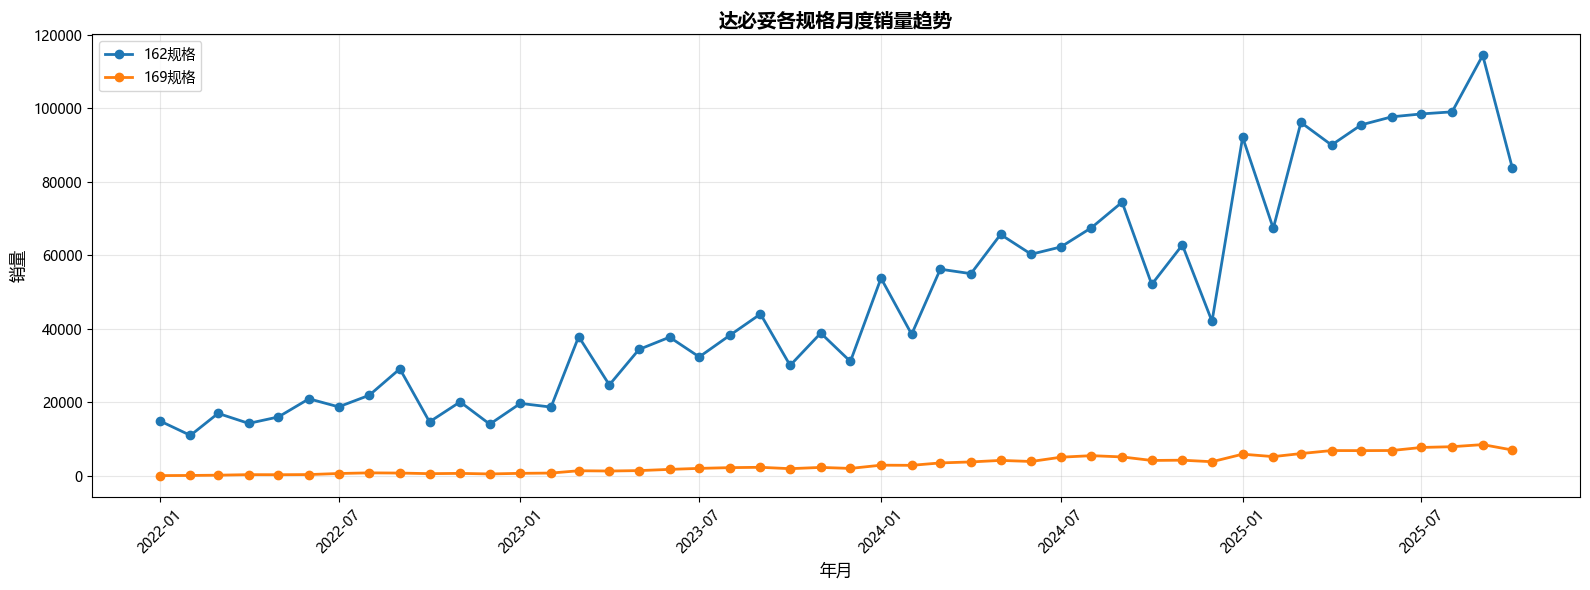

In [6]:
# 绘制月度销量趋势图
plt.figure(figsize=(16, 6))

for spec in monthly_sales['规格'].unique():
    spec_data = monthly_sales[monthly_sales['规格'] == spec]
    plt.plot(spec_data['年月'], spec_data['qty'], marker='o', label=f'{spec}规格', linewidth=2)

plt.title('达必妥各规格月度销量趋势', fontsize=14, fontweight='bold')
plt.xlabel('年月', fontsize=12)
plt.ylabel('销量', fontsize=12)
plt.legend(fontsize=10)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 整体预测-20251222

## 医保区间处理-162

【达必妥162规格：基于价格弹性调整剔除降价累积影响】

【第一步：数据准备】

✓ 162规格数据准备完成
  时间范围: 2022-01 ~ 2025-10
  总月数: 46
  销量范围: 10964 ~ 114336

【第二步：添加价格信息】

✓ 价格信息已添加

【步骤1：识别价格变动和影响区间】
----------------------------------------------------------------------

价格区间划分（降价影响的持续范围）:
  区间0: 2022-01 ~ 2023-12 (24个月) 
    平均价格: 3160.00元
    平均销量: 24,982
  区间1: 2024-01 ~ 2024-12 (12个月) ✓ 降价起始
    平均价格: 2780.00元
    平均销量: 57,502
  区间2: 2025-01 ~ 2025-10 (10个月) ✓ 降价起始
    平均价格: 1508.00元
    平均销量: 93,377

【步骤2：估计自然增长率（基准区间）】
----------------------------------------------------------------------

✓ 从基准区间拟合得到年自然增长率: 0.3151 (31.51%)

【步骤3：估计价格弹性系数 + 自然增长系数】
----------------------------------------------------------------------

基准区间（区间0，最高价时期）:
  基准价格: 3160.00元
  基准销量: 24,982
  基准医院数: 1,328
  基准年份: 2022

各价格区间的价格弹性效应（已剔除自然增长）:
  区间0:
    价格: 3160.00元 (相对基准+0.0%)
    平均销量: 24,982
    自然增长系数: 1.00x
    价格效应倍数: 1.00x (剔除自然增长后)
  区间1:
    价格: 2780.00元 (相对基准-12.0%)
    平均销量: 57,502
    自然增长系数: 2.68x
    价格效应倍数: 0.86x (剔除自然增长后)
  区间2:


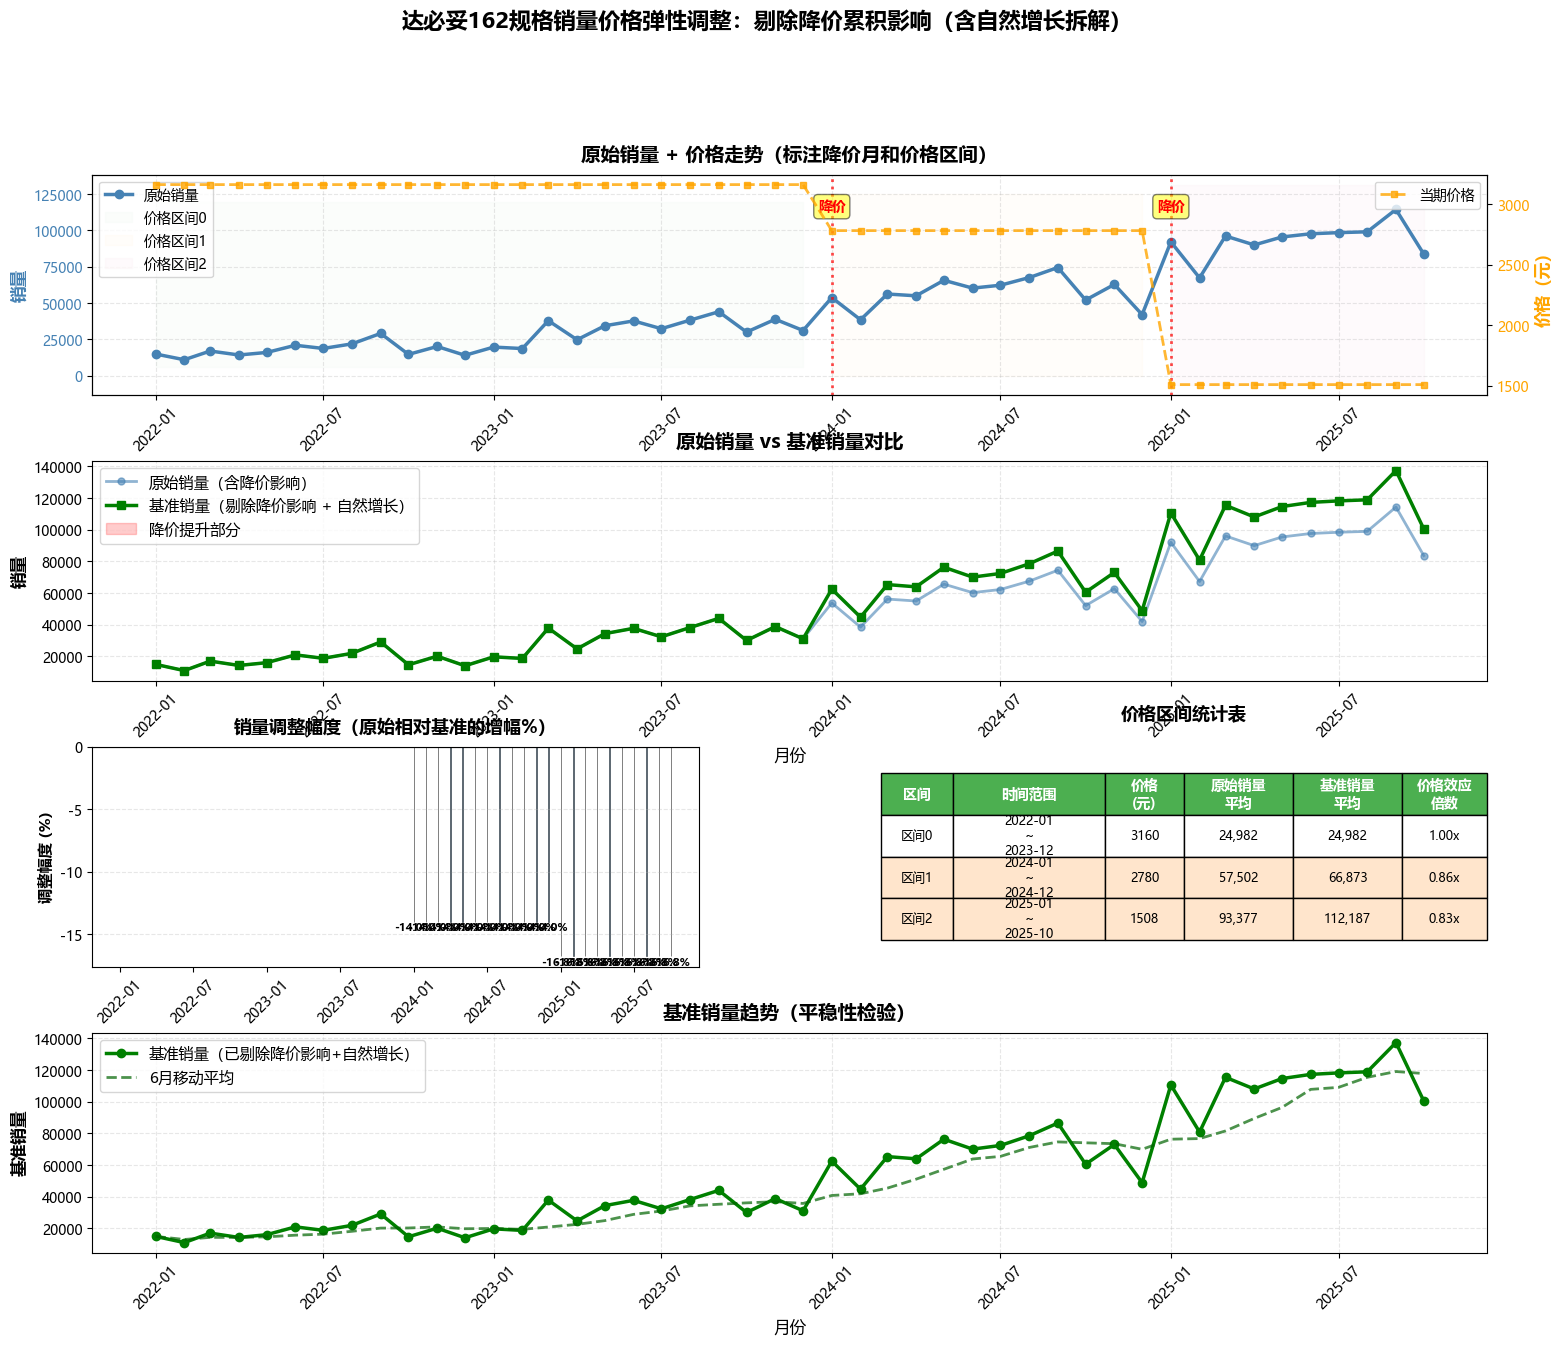


✅ 可视化完成

【处理后的数据详情（前20行）】
----------------------------------------------------------------------
        年月   当期价格  价格区间ID    当期总销量    销量_基准  销量调整幅度  是否降价月
2022-01-01 3160.0       0 14910.50 14910.50     0.0      0
2022-02-01 3160.0       0 10964.50 10964.50     0.0      0
2022-03-01 3160.0       0 16957.50 16957.50     0.0      0
2022-04-01 3160.0       0 14229.50 14229.50     0.0      0
2022-05-01 3160.0       0 15979.50 15979.50     0.0      0
2022-06-01 3160.0       0 20915.00 20915.00     0.0      0
2022-07-01 3160.0       0 18726.50 18726.50     0.0      0
2022-08-01 3160.0       0 21878.00 21878.00     0.0      0
2022-09-01 3160.0       0 29062.00 29062.00     0.0      0
2022-10-01 3160.0       0 14644.00 14644.00     0.0      0
2022-11-01 3160.0       0 20074.50 20074.50     0.0      0
2022-12-01 3160.0       0 14014.50 14014.50     0.0      0
2023-01-01 3160.0       0 19668.00 19668.00     0.0      0
2023-02-01 3160.0       0 18661.00 18661.00     0.0      0
2023-03-01 3160.0

In [7]:
"""
达必妥162规格：基于价格弹性调整剔除降价累积影响
参考：达必妥销量预测-251204.ipynb 的价格弹性调整方法
目标：将实际销量调整到基准水平（剔除降价影响），同时考虑自然增长因素
"""

print("="*90)
print("【达必妥162规格：基于价格弹性调整剔除降价累积影响】")
print("="*90)

# ============================================================
# 第一步：数据准备（使用已加载的df_all数据）
# ============================================================

print("\n" + "="*90)
print("【第一步：数据准备】")
print("="*90)

# 筛选162规格数据
df_nat = df_all[df_all['规格'] == '162'].copy()

# 按月汇总销量和活跃医院数
df_nat = df_nat.groupby('年月', as_index=False).agg({
    'qty': 'sum',
    'tophncode': 'nunique' if 'tophncode' in df_nat.columns else 'count'
})
df_nat = df_nat.rename(columns={'qty': '当期总销量', 'tophncode': '当期活跃医院数'})
df_nat = df_nat.sort_values('年月').reset_index(drop=True)

print(f"\n✓ 162规格数据准备完成")
print(f"  时间范围: {df_nat['年月'].min().strftime('%Y-%m')} ~ {df_nat['年月'].max().strftime('%Y-%m')}")
print(f"  总月数: {len(df_nat)}")
print(f"  销量范围: {df_nat['当期总销量'].min():.0f} ~ {df_nat['当期总销量'].max():.0f}")

# ============================================================
# 2. 添加基础特征
# ============================================================

df_nat['time_index'] = np.arange(len(df_nat))
df_nat['季度'] = df_nat['年月'].dt.quarter
spring_festival_months = {2022: 2, 2023: 1, 2024: 2, 2025: 1, 2026: 2, 2027: 2, 2028: 1, 2029: 2, 2030: 2}
df_nat['是否春节月'] = df_nat.apply(
    lambda r: 1 if spring_festival_months.get(r['年月'].year) == r['年月'].month else 0,
    axis=1
)

# ============================================================
# 3. 添加价格信息（162规格价格历史）
# ============================================================

print("\n" + "="*90)
print("【第二步：添加价格信息】")
print("="*90)

# 162规格价格历史（根据实际医保谈判情况）
def get_price_162(date):
    """获取162规格在指定时间的价格"""
    if date < pd.Timestamp('2024-01-01'):
        return 3160.0  # 2022-2023高价期
    elif date < pd.Timestamp('2025-01-01'):
        return 2780.0  # 2024年整年中价期
    else:
        return 1508.0  # 2025年之后低价期

df_nat['当期价格'] = df_nat['年月'].apply(get_price_162)

# 标记降价月
df_nat['是否降价月'] = 0
df_nat.loc[df_nat['年月'] == pd.Timestamp('2024-01-01'), '是否降价月'] = 1
df_nat.loc[df_nat['年月'] == pd.Timestamp('2025-01-01'), '是否降价月'] = 1

print(f"\n✓ 价格信息已添加")

# ============================================================
# 4. 识别价格区间（降价影响范围）
# ============================================================

print("\n【步骤1：识别价格变动和影响区间】")
print("-" * 70)

# 计算价格变动
df_nat['价格变动'] = df_nat['当期价格'].diff()
df_nat['是否价格下降'] = (df_nat['价格变动'] < -100).astype(int)

# 标记价格区间ID（每次降价后进入新区间）
价格区间列表 = []
当前区间ID = 0

for idx, row in df_nat.iterrows():
    if row['是否价格下降'] == 1:
        当前区间ID += 1
    价格区间列表.append(当前区间ID)

df_nat['价格区间ID'] = 价格区间列表

# 打印价格区间详情
print("\n价格区间划分（降价影响的持续范围）:")
for 区间ID in sorted(df_nat['价格区间ID'].unique()):
    区间数据 = df_nat[df_nat['价格区间ID'] == 区间ID]
    起始月 = 区间数据['年月'].min()
    结束月 = 区间数据['年月'].max()
    平均价格 = 区间数据['当期价格'].mean()
    平均销量 = 区间数据['当期总销量'].mean()
    月数 = len(区间数据)
    
    # 检查是否包含降价月
    降价标记 = "✓ 降价起始" if (区间数据['是否降价月'] == 1).any() else ""
    
    print(f"  区间{区间ID}: {起始月.strftime('%Y-%m')} ~ {结束月.strftime('%Y-%m')} ({月数}个月) {降价标记}")
    print(f"    平均价格: {平均价格:.2f}元")
    print(f"    平均销量: {平均销量:,.0f}")

# ============================================================
# 5. 估计自然增长率（从基准区间）
# ============================================================

print("\n【步骤2：估计自然增长率（基准区间）】")
print("-" * 70)

# 筛选基准区间数据
df_baseline = df_nat[df_nat['价格区间ID'] == 0].copy()

if len(df_baseline) > 0:
    # 按年度计算单院销量
    df_baseline['年份'] = df_baseline['年月'].dt.year
    
    yearly_stats = df_baseline.groupby('年份').agg({
        '当期总销量': 'mean',
        '当期活跃医院数': 'mean'
    }).reset_index()
    
    yearly_stats['单院销量'] = yearly_stats['当期总销量'] / yearly_stats['当期活跃医院数']
    yearly_stats['年增长率'] = yearly_stats['单院销量'].pct_change()
    
    growth_rates = yearly_stats['年增长率'].dropna()
    
    if len(growth_rates) > 0:
        annual_growth_rate = growth_rates.median()
        print(f"\n✓ 从基准区间拟合得到年自然增长率: {annual_growth_rate:.4f} ({annual_growth_rate*100:.2f}%)")
    else:
        annual_growth_rate = 0.20
        print(f"\n⚠️ 基准区间数据不足，使用默认年增长率: {annual_growth_rate:.4f}")
else:
    annual_growth_rate = 0.20
    print(f"\n⚠️ 无基准区间数据，使用默认年增长率: {annual_growth_rate:.4f}")

# ============================================================
# 6. 计算价格弹性与自然增长系数
# ============================================================

print("\n【步骤3：估计价格弹性系数 + 自然增长系数】")
print("-" * 70)

# 以区间0（最高价）作为基准
区间0数据 = df_nat[df_nat['价格区间ID'] == 0]
基准销量 = 区间0数据['当期总销量'].mean()
基准价格 = 区间0数据['当期价格'].mean()
基准医院数 = 区间0数据['当期活跃医院数'].mean()
基准年份 = 区间0数据['年月'].min().year

print(f"\n基准区间（区间0，最高价时期）:")
print(f"  基准价格: {基准价格:.2f}元")
print(f"  基准销量: {基准销量:,.0f}")
print(f"  基准医院数: {基准医院数:,.0f}")
print(f"  基准年份: {基准年份}")

# 计算各区间相对基准的销量提升倍数（剔除自然增长后）
区间提升倍数 = {}
区间平均价格 = {}
区间自然增长系数 = {}

print(f"\n各价格区间的价格弹性效应（已剔除自然增长）:")
for 区间ID in sorted(df_nat['价格区间ID'].unique()):
    区间数据 = df_nat[df_nat['价格区间ID'] == 区间ID]
    区间销量 = 区间数据['当期总销量'].mean()
    区间价格 = 区间数据['当期价格'].mean()
    区间医院数 = 区间数据['当期活跃医院数'].mean()
    区间起始年份 = 区间数据['年月'].min().year
    
    if 区间ID == 0:
        自然增长系数 = 1.0
        提升倍数 = 1.0
    else:
        # 计算年份跨度
        years_elapsed = 区间起始年份 - 基准年份
        
        # 医院数增长倍数
        hosp_growth_mult = 区间医院数 / 基准医院数
        
        # 单院自然增长系数
        per_hosp_growth_coef = (1 + annual_growth_rate) ** years_elapsed
        
        # 自然增长系数 = 医院数增长 × 单院增长
        自然增长系数 = hosp_growth_mult * per_hosp_growth_coef
        
        # 实际增长倍数
        actual_growth_mult = 区间销量 / 基准销量
        
        # 价格效应倍数 = 实际增长 / 自然增长
        提升倍数 = actual_growth_mult / 自然增长系数
    
    区间提升倍数[区间ID] = 提升倍数
    区间平均价格[区间ID] = 区间价格
    区间自然增长系数[区间ID] = 自然增长系数
    
    价格降幅 = ((区间价格 - 基准价格) / 基准价格) * 100 if 区间ID > 0 else 0
    
    print(f"  区间{区间ID}:")
    print(f"    价格: {区间价格:.2f}元 (相对基准{价格降幅:+.1f}%)")
    print(f"    平均销量: {区间销量:,.0f}")
    print(f"    自然增长系数: {自然增长系数:.2f}x")
    print(f"    价格效应倍数: {提升倍数:.2f}x (剔除自然增长后)")

# ============================================================
# 7. 调整销量到基准水平（剔除降价影响）
# ============================================================

print("\n【步骤4：将各区间销量调整到基准水平】")
print("-" * 70)

# 创建基准销量列
df_nat['销量_基准'] = df_nat.apply(
    lambda row: row['当期总销量'] / 区间提升倍数[row['价格区间ID']],
    axis=1
)

# 打印调整效果
print("\n调整效果汇总:")
for 区间ID in sorted(df_nat['价格区间ID'].unique()):
    区间数据 = df_nat[df_nat['价格区间ID'] == 区间ID]
    原始销量 = 区间数据['当期总销量'].mean()
    基准销量_调整后 = 区间数据['销量_基准'].mean()
    调整系数 = 区间提升倍数[区间ID]
    自然增长 = 区间自然增长系数[区间ID]
    
    print(f"  区间{区间ID}:")
    print(f"    原始销量: {原始销量:,.0f}")
    print(f"    基准销量: {基准销量_调整后:,.0f}")
    print(f"    自然增长系数: {自然增长:.2f}x")
    print(f"    价格效应倍数: {调整系数:.2f}x")
    print(f"    调整方法: 原始销量 ÷ {调整系数:.2f}")

# 计算调整幅度
df_nat['销量调整幅度'] = ((df_nat['当期总销量'] - df_nat['销量_基准']) / df_nat['销量_基准']) * 100

# ============================================================
# 8. 可视化对比
# ============================================================

print("\n【步骤5：生成可视化对比】")
print("-" * 70)

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(4, 2, hspace=0.3, wspace=0.3)

# --- 子图1: 原始销量 + 价格（双轴）---
ax1 = fig.add_subplot(gs[0, :])
ax1_price = ax1.twinx()

# 销量线
ax1.plot(df_nat['年月'], df_nat['当期总销量'], 
         marker='o', linewidth=2.5, label='原始销量', color='steelblue', markersize=6)

# 价格线
ax1_price.plot(df_nat['年月'], df_nat['当期价格'], 
               marker='s', linewidth=2, linestyle='--', label='当期价格', 
               color='orange', markersize=5, alpha=0.8)

# 标注降价月
降价月份_list = df_nat[df_nat['是否降价月'] == 1]['年月'].tolist()
for 降价月 in 降价月份_list:
    ax1.axvline(降价月, color='red', linestyle=':', linewidth=2, alpha=0.7)
    y_pos = ax1.get_ylim()[1] * 0.95
    ax1.text(降价月, y_pos, '降价', color='red', fontsize=10, ha='center', 
             fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

# 用背景色区分价格区间
colors_区间 = ['#E8F5E9', '#FFF3E0', '#FCE4EC']
for 区间ID in sorted(df_nat['价格区间ID'].unique()):
    区间数据 = df_nat[df_nat['价格区间ID'] == 区间ID]
    if 区间ID < len(colors_区间):
        ax1.fill_between(区间数据['年月'], 
                         ax1.get_ylim()[0], ax1.get_ylim()[1],
                         alpha=0.15, color=colors_区间[区间ID], 
                         label=f'价格区间{区间ID}')

ax1.set_title('原始销量 + 价格走势（标注降价月和价格区间）', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('月份', fontsize=12)
ax1.set_ylabel('销量', fontsize=12, color='steelblue', fontweight='bold')
ax1_price.set_ylabel('价格（元）', fontsize=12, color='orange', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1_price.tick_params(axis='y', labelcolor='orange')
ax1.legend(loc='upper left', fontsize=10)
ax1_price.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.tick_params(axis='x', rotation=45)

# --- 子图2: 原始销量 vs 基准销量 ---
ax2 = fig.add_subplot(gs[1, :])

ax2.plot(df_nat['年月'], df_nat['当期总销量'], 
         marker='o', linewidth=2, label='原始销量（含降价影响）', 
         color='steelblue', markersize=5, alpha=0.6, linestyle='-')
ax2.plot(df_nat['年月'], df_nat['销量_基准'], 
         marker='s', linewidth=2.5, label='基准销量（剔除降价影响 + 自然增长）', 
         color='green', markersize=6, linestyle='-')

# 填充差异区域
ax2.fill_between(df_nat['年月'], df_nat['当期总销量'], df_nat['销量_基准'],
                 where=(df_nat['当期总销量'] > df_nat['销量_基准']),
                 alpha=0.2, color='red', label='降价提升部分')

ax2.set_title('原始销量 vs 基准销量对比', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('月份', fontsize=12)
ax2.set_ylabel('销量', fontsize=12, fontweight='bold')
ax2.legend(loc='upper left', fontsize=11)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.tick_params(axis='x', rotation=45)

# --- 子图3: 调整幅度柱状图 ---
ax3 = fig.add_subplot(gs[2, 0])

colors_bar = ['red' if x > 10 else 'orange' if x > 0 else 'steelblue' 
              for x in df_nat['销量调整幅度']]

bars = ax3.bar(df_nat['年月'], df_nat['销量调整幅度'], 
               color=colors_bar, alpha=0.7, edgecolor='black', linewidth=0.5)

# 标注具体数值（只标注>10%的）
for i, (idx, row) in enumerate(df_nat.iterrows()):
    if abs(row['销量调整幅度']) > 10:
        ax3.text(row['年月'], row['销量调整幅度'], 
                f"{row['销量调整幅度']:.1f}%",
                ha='center', va='bottom' if row['销量调整幅度'] > 0 else 'top',
                fontsize=8, fontweight='bold')

ax3.axhline(0, color='black', linewidth=1.5)
ax3.set_title('销量调整幅度（原始相对基准的增幅%）', fontsize=13, fontweight='bold', pad=10)
ax3.set_xlabel('月份', fontsize=11)
ax3.set_ylabel('调整幅度 (%)', fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3, linestyle='--', axis='y')
ax3.tick_params(axis='x', rotation=45)

# --- 子图4: 价格区间统计表 ---
ax4 = fig.add_subplot(gs[2, 1])
ax4.axis('off')

# 准备表格数据
table_data = []
for 区间ID in sorted(df_nat['价格区间ID'].unique()):
    区间数据 = df_nat[df_nat['价格区间ID'] == 区间ID]
    起始月 = 区间数据['年月'].min().strftime('%Y-%m')
    结束月 = 区间数据['年月'].max().strftime('%Y-%m')
    区间价格 = 区间平均价格[区间ID]
    原始销量 = 区间数据['当期总销量'].mean()
    基准销量 = 区间数据['销量_基准'].mean()
    提升倍数 = 区间提升倍数[区间ID]
    
    table_data.append([
        f"区间{区间ID}",
        f"{起始月}\n~\n{结束月}",
        f"{区间价格:.0f}",
        f"{原始销量:,.0f}",
        f"{基准销量:,.0f}",
        f"{提升倍数:.2f}x"
    ])

table = ax4.table(cellText=table_data,
                  colLabels=['区间', '时间范围', '价格\n(元)', '原始销量\n平均', '基准销量\n平均', '价格效应\n倍数'],
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.12, 0.25, 0.13, 0.18, 0.18, 0.14])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.5)

# 设置表头样式
for i in range(6):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white', fontsize=10)

# 设置行颜色
for i in range(1, len(table_data) + 1):
    for j in range(6):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')
        # 高亮降价区间
        if i > 1:  # 区间1及以后是降价区间
            table[(i, j)].set_facecolor('#FFE5CC')

ax4.set_title('价格区间统计表', fontsize=13, fontweight='bold', pad=20)

# --- 子图5: 基准销量趋势（平稳性检验）---
ax5 = fig.add_subplot(gs[3, :])

ax5.plot(df_nat['年月'], df_nat['销量_基准'], 
         marker='o', linewidth=2.5, label='基准销量（已剔除降价影响+自然增长）', 
         color='green', markersize=6)

# 添加移动平均线
窗口 = 6
df_nat['销量_基准_MA'] = df_nat['销量_基准'].rolling(window=窗口, min_periods=1).mean()
ax5.plot(df_nat['年月'], df_nat['销量_基准_MA'], 
         linewidth=2, linestyle='--', label=f'{窗口}月移动平均', 
         color='darkgreen', alpha=0.7)

ax5.set_title('基准销量趋势（平稳性检验）', fontsize=14, fontweight='bold', pad=10)
ax5.set_xlabel('月份', fontsize=12)
ax5.set_ylabel('基准销量', fontsize=12, fontweight='bold')
ax5.legend(loc='upper left', fontsize=11)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.tick_params(axis='x', rotation=45)

plt.suptitle('达必妥162规格销量价格弹性调整：剔除降价累积影响（含自然增长拆解）', 
             fontsize=16, fontweight='bold', y=0.998)

plt.tight_layout()
plt.show()

print(f"\n✅ 可视化完成")

# ============================================================
# 9. 输出详细数据
# ============================================================

print("\n【处理后的数据详情（前20行）】")
print("-" * 70)

显示列 = ['年月', '当期价格', '价格区间ID', '当期总销量', '销量_基准', '销量调整幅度', '是否降价月']
print(df_nat[显示列].head(20).to_string(index=False))

print("\n【处理后的数据详情（后20行）】")
print("-" * 70)
print(df_nat[显示列].tail(20).to_string(index=False))

# 统计信息
print("\n【统计摘要】")
print("-" * 70)
print(f"总月数: {len(df_nat)}")
print(f"价格区间数: {df_nat['价格区间ID'].nunique()}")
print(f"原始销量均值: {df_nat['当期总销量'].mean():,.0f}")
print(f"基准销量均值: {df_nat['销量_基准'].mean():,.0f}")
print(f"平均调整幅度: {df_nat['销量调整幅度'].mean():.2f}%")
print(f"最大调整幅度: {df_nat['销量调整幅度'].max():.2f}%")

print("\n" + "="*90)
print("【价格弹性调整完成】")
print("="*90)
print("✅ 销量已调整到基准水平（剔除降价累积影响 + 自然增长拆解）")
print(f"\n✅ 各区间价格效应倍数（已剔除自然增长）：")
for 区间ID, 倍数 in 区间提升倍数.items():
    自然增长 = 区间自然增长系数[区间ID]
    print(f"  区间{区间ID}: 自然增长系数={自然增长:.2f}x, 价格效应倍数={倍数:.2f}x")

print(f"\n✅ 建模建议：")
print(f"  1. 使用'销量_基准'作为目标变量进行建模")
print(f"  2. 预测时还原公式: 实际销量 = 基准销量预测 × 当前价格效应倍数")
print(f"  3. 当前（最新区间）价格效应倍数: {区间提升倍数[max(区间提升倍数.keys())]:.2f}x")

print("\n" + "="*90)

## 医保区间处理-169

【达必妥169规格：基于价格弹性调整剔除降价累积影响】

【第一步：数据准备】

✓ 169规格数据准备完成
  时间范围: 2022-01 ~ 2025-10
  总月数: 46
  销量范围: 29 ~ 8458

【第二步：添加价格信息】

✓ 价格信息已添加

【步骤1：识别价格变动和影响区间】
----------------------------------------------------------------------

价格区间划分（降价影响的持续范围）:
  区间0: 2022-01 ~ 2023-12 (24个月) 
    平均价格: 2980.00元
    平均销量: 1,023
  区间1: 2024-01 ~ 2024-12 (12个月) ✓ 降价起始
    平均价格: 2680.00元
    平均销量: 4,057
  区间2: 2025-01 ~ 2025-10 (10个月) ✓ 降价起始
    平均价格: 1408.00元
    平均销量: 6,860

【步骤2：估计自然增长率（基准区间）】
----------------------------------------------------------------------

✓ 从基准区间拟合得到年自然增长率: 0.2094 (20.94%)

【步骤3：估计价格弹性系数 + 自然增长系数】
----------------------------------------------------------------------

基准区间（区间0，最高价时期）:
  基准价格: 2980.00元
  基准销量: 1,023
  基准医院数: 229
  基准年份: 2022

各价格区间的价格弹性效应（已剔除自然增长）:
  区间0:
    价格: 2980.00元 (相对基准+0.0%)
    平均销量: 1,023
    自然增长系数: 1.00x
    价格效应倍数: 1.00x (剔除自然增长后)
  区间1:
    价格: 2680.00元 (相对基准-10.1%)
    平均销量: 4,057
    自然增长系数: 4.30x
    价格效应倍数: 0.92x (剔除自然增长后)
  区间2:
    价格: 1408.

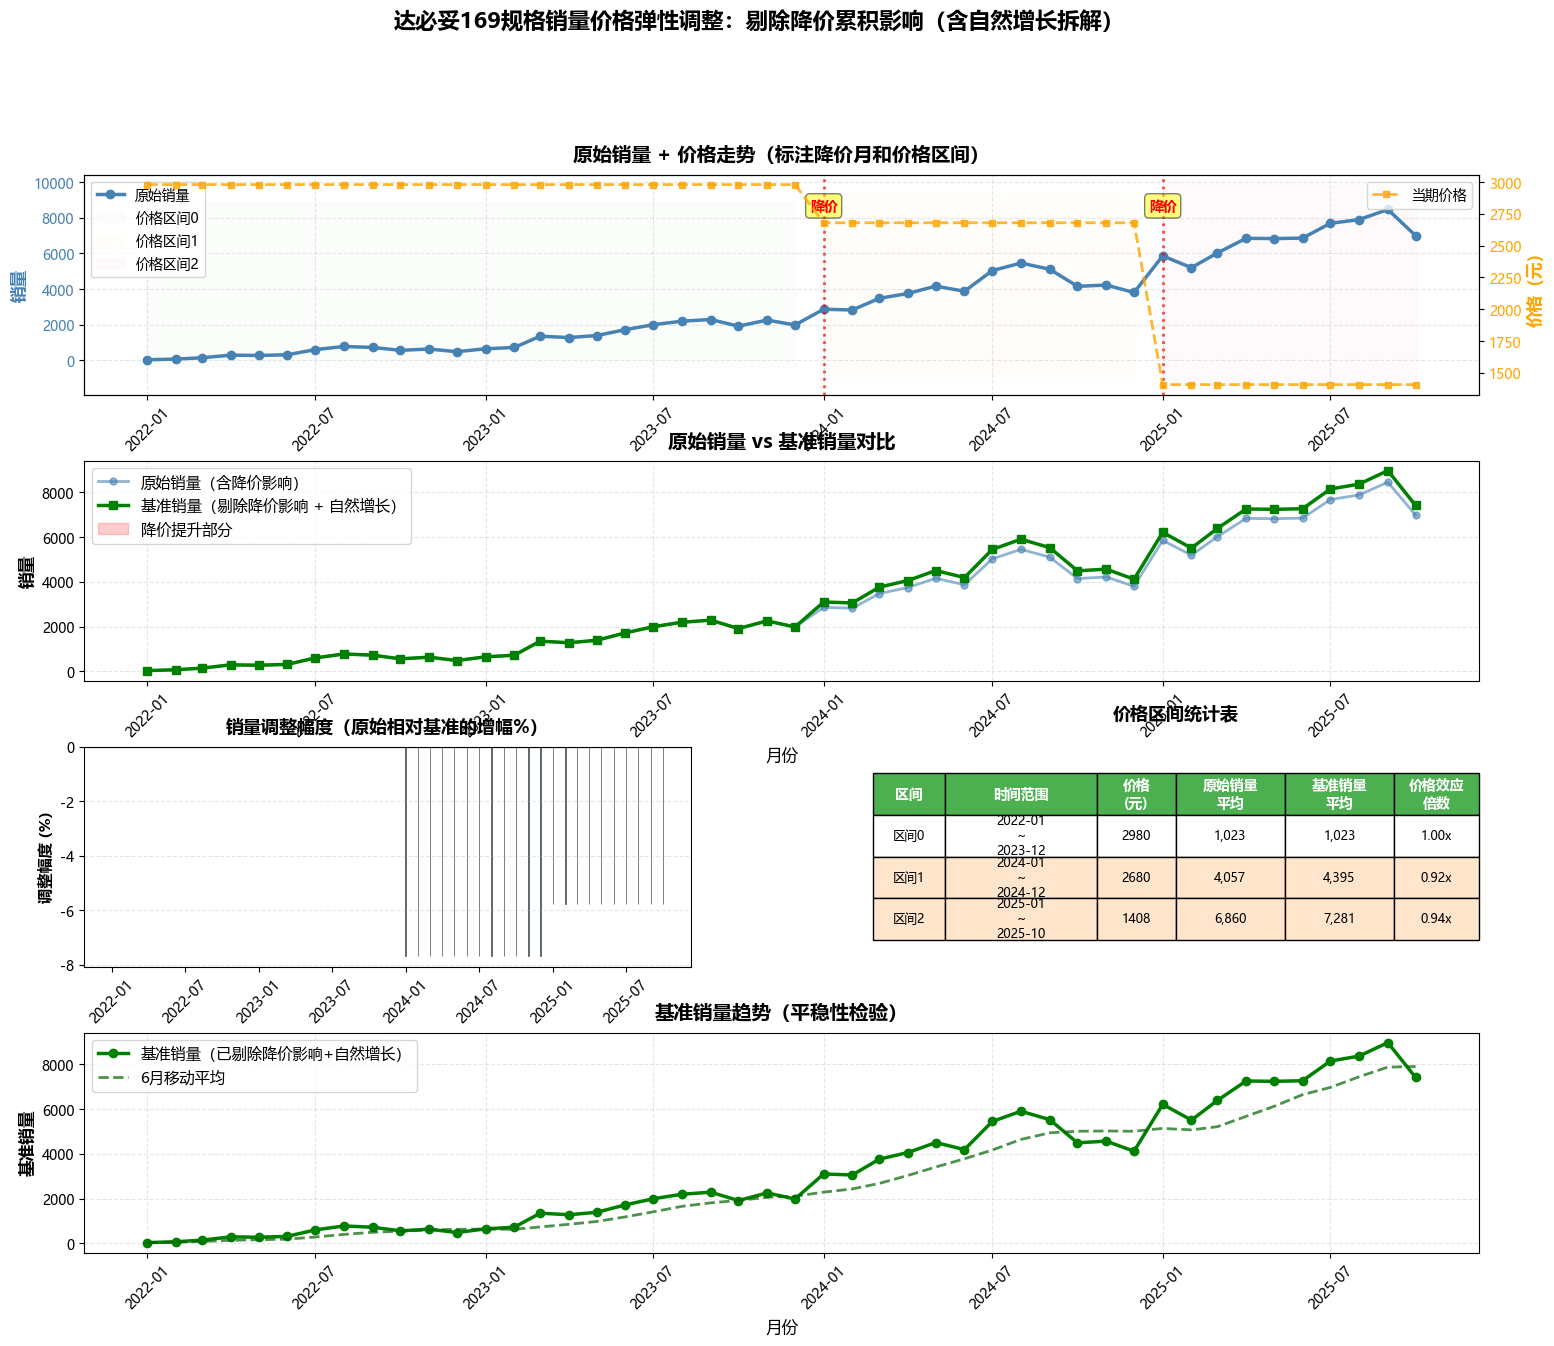


✅ 可视化完成

【处理后的数据详情（前20行）】
----------------------------------------------------------------------
        年月   当期价格  价格区间ID  当期总销量  销量_基准  销量调整幅度  是否降价月
2022-01-01 2980.0       0   29.0   29.0     0.0      0
2022-02-01 2980.0       0   67.0   67.0     0.0      0
2022-03-01 2980.0       0  139.5  139.5     0.0      0
2022-04-01 2980.0       0  287.5  287.5     0.0      0
2022-05-01 2980.0       0  269.0  269.0     0.0      0
2022-06-01 2980.0       0  308.0  308.0     0.0      0
2022-07-01 2980.0       0  596.5  596.5     0.0      0
2022-08-01 2980.0       0  772.5  772.5     0.0      0
2022-09-01 2980.0       0  719.5  719.5     0.0      0
2022-10-01 2980.0       0  556.0  556.0     0.0      0
2022-11-01 2980.0       0  629.5  629.5     0.0      0
2022-12-01 2980.0       0  480.0  480.0     0.0      0
2023-01-01 2980.0       0  643.5  643.5     0.0      0
2023-02-01 2980.0       0  718.5  718.5     0.0      0
2023-03-01 2980.0       0 1346.5 1346.5     0.0      0
2023-04-01 2980.0     

In [8]:
"""
达必妥169规格：基于价格弹性调整剔除降价累积影响
参考：达必妥销量预测-251204.ipynb 的价格弹性调整方法
目标：将实际销量调整到基准水平（剔除降价影响），同时考虑自然增长因素
"""

print("="*90)
print("【达必妥169规格：基于价格弹性调整剔除降价累积影响】")
print("="*90)

# ============================================================
# 第一步：数据准备（使用已加载的df_all数据）
# ============================================================

print("\n" + "="*90)
print("【第一步：数据准备】")
print("="*90)

# 筛选169规格数据
df_nat_169 = df_all[df_all['规格'] == '169'].copy()

# 按月汇总销量和活跃医院数
df_nat_169 = df_nat_169.groupby('年月', as_index=False).agg({
    'qty': 'sum',
    'tophncode': 'nunique' if 'tophncode' in df_nat_169.columns else 'count'
})
df_nat_169 = df_nat_169.rename(columns={'qty': '当期总销量', 'tophncode': '当期活跃医院数'})
df_nat_169 = df_nat_169.sort_values('年月').reset_index(drop=True)

print(f"\n✓ 169规格数据准备完成")
print(f"  时间范围: {df_nat_169['年月'].min().strftime('%Y-%m')} ~ {df_nat_169['年月'].max().strftime('%Y-%m')}")
print(f"  总月数: {len(df_nat_169)}")
print(f"  销量范围: {df_nat_169['当期总销量'].min():.0f} ~ {df_nat_169['当期总销量'].max():.0f}")

# ============================================================
# 2. 添加基础特征
# ============================================================

df_nat_169['time_index'] = np.arange(len(df_nat_169))
df_nat_169['季度'] = df_nat_169['年月'].dt.quarter
spring_festival_months = {2022: 2, 2023: 1, 2024: 2, 2025: 1, 2026: 2, 2027: 2, 2028: 1, 2029: 2, 2030: 2}
df_nat_169['是否春节月'] = df_nat_169.apply(
    lambda r: 1 if spring_festival_months.get(r['年月'].year) == r['年月'].month else 0,
    axis=1
)

# ============================================================
# 3. 添加价格信息（169规格价格历史）
# ============================================================

print("\n" + "="*90)
print("【第二步：添加价格信息】")
print("="*90)

# 169规格价格历史（根据实际医保谈判情况）
def get_price_169(date):
    """获取169规格在指定时间的价格"""
    if date < pd.Timestamp('2024-01-01'):
        return 2980.0  # 2022-2023高价期
    elif date < pd.Timestamp('2025-01-01'):
        return 2680.0  # 2024年整年中价期
    else:
        return 1408.0  # 2025年之后低价期

df_nat_169['当期价格'] = df_nat_169['年月'].apply(get_price_169)

# 标记降价月
df_nat_169['是否降价月'] = 0
df_nat_169.loc[df_nat_169['年月'] == pd.Timestamp('2024-01-01'), '是否降价月'] = 1
df_nat_169.loc[df_nat_169['年月'] == pd.Timestamp('2025-01-01'), '是否降价月'] = 1

print(f"\n✓ 价格信息已添加")

# ============================================================
# 4. 识别价格区间（降价影响范围）
# ============================================================

print("\n【步骤1：识别价格变动和影响区间】")
print("-" * 70)

# 计算价格变动
df_nat_169['价格变动'] = df_nat_169['当期价格'].diff()
df_nat_169['是否价格下降'] = (df_nat_169['价格变动'] < -100).astype(int)

# 标记价格区间ID（每次降价后进入新区间）
价格区间列表_169 = []
当前区间ID_169 = 0

for idx, row in df_nat_169.iterrows():
    if row['是否价格下降'] == 1:
        当前区间ID_169 += 1
    价格区间列表_169.append(当前区间ID_169)

df_nat_169['价格区间ID'] = 价格区间列表_169

# 打印价格区间详情
print("\n价格区间划分（降价影响的持续范围）:")
for 区间ID in sorted(df_nat_169['价格区间ID'].unique()):
    区间数据 = df_nat_169[df_nat_169['价格区间ID'] == 区间ID]
    起始月 = 区间数据['年月'].min()
    结束月 = 区间数据['年月'].max()
    平均价格 = 区间数据['当期价格'].mean()
    平均销量 = 区间数据['当期总销量'].mean()
    月数 = len(区间数据)
    
    # 检查是否包含降价月
    降价标记 = "✓ 降价起始" if (区间数据['是否降价月'] == 1).any() else ""
    
    print(f"  区间{区间ID}: {起始月.strftime('%Y-%m')} ~ {结束月.strftime('%Y-%m')} ({月数}个月) {降价标记}")
    print(f"    平均价格: {平均价格:.2f}元")
    print(f"    平均销量: {平均销量:,.0f}")

# ============================================================
# 5. 估计自然增长率（从基准区间）
# ============================================================

print("\n【步骤2：估计自然增长率（基准区间）】")
print("-" * 70)

# 筛选基准区间数据
df_baseline_169 = df_nat_169[df_nat_169['价格区间ID'] == 0].copy()

if len(df_baseline_169) > 0:
    # 按年度计算单院销量
    df_baseline_169['年份'] = df_baseline_169['年月'].dt.year
    
    yearly_stats_169 = df_baseline_169.groupby('年份').agg({
        '当期总销量': 'mean',
        '当期活跃医院数': 'mean'
    }).reset_index()
    
    yearly_stats_169['单院销量'] = yearly_stats_169['当期总销量'] / yearly_stats_169['当期活跃医院数']
    yearly_stats_169['年增长率'] = yearly_stats_169['单院销量'].pct_change()
    
    growth_rates_169 = yearly_stats_169['年增长率'].dropna()
    
    if len(growth_rates_169) > 0:
        annual_growth_rate_169 = growth_rates_169.median()
        print(f"\n✓ 从基准区间拟合得到年自然增长率: {annual_growth_rate_169:.4f} ({annual_growth_rate_169*100:.2f}%)")
    else:
        annual_growth_rate_169 = 0.20
        print(f"\n⚠️ 基准区间数据不足，使用默认年增长率: {annual_growth_rate_169:.4f}")
else:
    annual_growth_rate_169 = 0.20
    print(f"\n⚠️ 无基准区间数据，使用默认年增长率: {annual_growth_rate_169:.4f}")

# ============================================================
# 6. 计算价格弹性与自然增长系数
# ============================================================

print("\n【步骤3：估计价格弹性系数 + 自然增长系数】")
print("-" * 70)

# 以区间0（最高价）作为基准
区间0数据_169 = df_nat_169[df_nat_169['价格区间ID'] == 0]
基准销量_169 = 区间0数据_169['当期总销量'].mean()
基准价格_169 = 区间0数据_169['当期价格'].mean()
基准医院数_169 = 区间0数据_169['当期活跃医院数'].mean()
基准年份_169 = 区间0数据_169['年月'].min().year

print(f"\n基准区间（区间0，最高价时期）:")
print(f"  基准价格: {基准价格_169:.2f}元")
print(f"  基准销量: {基准销量_169:,.0f}")
print(f"  基准医院数: {基准医院数_169:,.0f}")
print(f"  基准年份: {基准年份_169}")

# 计算各区间相对基准的销量提升倍数（剔除自然增长后）
区间提升倍数_169 = {}
区间平均价格_169 = {}
区间自然增长系数_169 = {}

print(f"\n各价格区间的价格弹性效应（已剔除自然增长）:")
for 区间ID in sorted(df_nat_169['价格区间ID'].unique()):
    区间数据 = df_nat_169[df_nat_169['价格区间ID'] == 区间ID]
    区间销量 = 区间数据['当期总销量'].mean()
    区间价格 = 区间数据['当期价格'].mean()
    区间医院数 = 区间数据['当期活跃医院数'].mean()
    区间起始年份 = 区间数据['年月'].min().year
    
    if 区间ID == 0:
        自然增长系数 = 1.0
        提升倍数 = 1.0
    else:
        # 计算年份跨度
        years_elapsed = 区间起始年份 - 基准年份_169
        
        # 医院数增长倍数
        hosp_growth_mult = 区间医院数 / 基准医院数_169
        
        # 单院自然增长系数
        per_hosp_growth_coef = (1 + annual_growth_rate_169) ** years_elapsed
        
        # 自然增长系数 = 医院数增长 × 单院增长
        自然增长系数 = hosp_growth_mult * per_hosp_growth_coef
        
        # 实际增长倍数
        actual_growth_mult = 区间销量 / 基准销量_169
        
        # 价格效应倍数 = 实际增长 / 自然增长
        提升倍数 = actual_growth_mult / 自然增长系数
    
    区间提升倍数_169[区间ID] = 提升倍数
    区间平均价格_169[区间ID] = 区间价格
    区间自然增长系数_169[区间ID] = 自然增长系数
    
    价格降幅 = ((区间价格 - 基准价格_169) / 基准价格_169) * 100 if 区间ID > 0 else 0
    
    print(f"  区间{区间ID}:")
    print(f"    价格: {区间价格:.2f}元 (相对基准{价格降幅:+.1f}%)")
    print(f"    平均销量: {区间销量:,.0f}")
    print(f"    自然增长系数: {自然增长系数:.2f}x")
    print(f"    价格效应倍数: {提升倍数:.2f}x (剔除自然增长后)")

# ============================================================
# 7. 调整销量到基准水平（剔除降价影响）
# ============================================================

print("\n【步骤4：将各区间销量调整到基准水平】")
print("-" * 70)

# 创建基准销量列
df_nat_169['销量_基准'] = df_nat_169.apply(
    lambda row: row['当期总销量'] / 区间提升倍数_169[row['价格区间ID']],
    axis=1
)

# 打印调整效果
print("\n调整效果汇总:")
for 区间ID in sorted(df_nat_169['价格区间ID'].unique()):
    区间数据 = df_nat_169[df_nat_169['价格区间ID'] == 区间ID]
    原始销量 = 区间数据['当期总销量'].mean()
    基准销量_调整后 = 区间数据['销量_基准'].mean()
    调整系数 = 区间提升倍数_169[区间ID]
    自然增长 = 区间自然增长系数_169[区间ID]
    
    print(f"  区间{区间ID}:")
    print(f"    原始销量: {原始销量:,.0f}")
    print(f"    基准销量: {基准销量_调整后:,.0f}")
    print(f"    自然增长系数: {自然增长:.2f}x")
    print(f"    价格效应倍数: {调整系数:.2f}x")
    print(f"    调整方法: 原始销量 ÷ {调整系数:.2f}")

# 计算调整幅度
df_nat_169['销量调整幅度'] = ((df_nat_169['当期总销量'] - df_nat_169['销量_基准']) / df_nat_169['销量_基准']) * 100

# ============================================================
# 8. 可视化对比
# ============================================================

print("\n【步骤5：生成可视化对比】")
print("-" * 70)

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(4, 2, hspace=0.3, wspace=0.3)

# --- 子图1: 原始销量 + 价格（双轴）---
ax1 = fig.add_subplot(gs[0, :])
ax1_price = ax1.twinx()

# 销量线
ax1.plot(df_nat_169['年月'], df_nat_169['当期总销量'], 
         marker='o', linewidth=2.5, label='原始销量', color='steelblue', markersize=6)

# 价格线
ax1_price.plot(df_nat_169['年月'], df_nat_169['当期价格'], 
               marker='s', linewidth=2, linestyle='--', label='当期价格', 
               color='orange', markersize=5, alpha=0.8)

# 标注降价月
降价月份_list_169 = df_nat_169[df_nat_169['是否降价月'] == 1]['年月'].tolist()
for 降价月 in 降价月份_list_169:
    ax1.axvline(降价月, color='red', linestyle=':', linewidth=2, alpha=0.7)
    y_pos = ax1.get_ylim()[1] * 0.95
    ax1.text(降价月, y_pos, '降价', color='red', fontsize=10, ha='center', 
             fontweight='bold', bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

# 用背景色区分价格区间
colors_区间 = ['#E8F5E9', '#FFF3E0', '#FCE4EC']
for 区间ID in sorted(df_nat_169['价格区间ID'].unique()):
    区间数据 = df_nat_169[df_nat_169['价格区间ID'] == 区间ID]
    if 区间ID < len(colors_区间):
        ax1.fill_between(区间数据['年月'], 
                         ax1.get_ylim()[0], ax1.get_ylim()[1],
                         alpha=0.15, color=colors_区间[区间ID], 
                         label=f'价格区间{区间ID}')

ax1.set_title('原始销量 + 价格走势（标注降价月和价格区间）', fontsize=14, fontweight='bold', pad=10)
ax1.set_xlabel('月份', fontsize=12)
ax1.set_ylabel('销量', fontsize=12, color='steelblue', fontweight='bold')
ax1_price.set_ylabel('价格（元）', fontsize=12, color='orange', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1_price.tick_params(axis='y', labelcolor='orange')
ax1.legend(loc='upper left', fontsize=10)
ax1_price.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.tick_params(axis='x', rotation=45)

# --- 子图2: 原始销量 vs 基准销量 ---
ax2 = fig.add_subplot(gs[1, :])

ax2.plot(df_nat_169['年月'], df_nat_169['当期总销量'], 
         marker='o', linewidth=2, label='原始销量（含降价影响）', 
         color='steelblue', markersize=5, alpha=0.6, linestyle='-')
ax2.plot(df_nat_169['年月'], df_nat_169['销量_基准'], 
         marker='s', linewidth=2.5, label='基准销量（剔除降价影响 + 自然增长）', 
         color='green', markersize=6, linestyle='-')

# 填充差异区域
ax2.fill_between(df_nat_169['年月'], df_nat_169['当期总销量'], df_nat_169['销量_基准'],
                 where=(df_nat_169['当期总销量'] > df_nat_169['销量_基准']),
                 alpha=0.2, color='red', label='降价提升部分')

ax2.set_title('原始销量 vs 基准销量对比', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('月份', fontsize=12)
ax2.set_ylabel('销量', fontsize=12, fontweight='bold')
ax2.legend(loc='upper left', fontsize=11)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.tick_params(axis='x', rotation=45)

# --- 子图3: 调整幅度柱状图 ---
ax3 = fig.add_subplot(gs[2, 0])

colors_bar = ['red' if x > 10 else 'orange' if x > 0 else 'steelblue' 
              for x in df_nat_169['销量调整幅度']]

bars = ax3.bar(df_nat_169['年月'], df_nat_169['销量调整幅度'], 
               color=colors_bar, alpha=0.7, edgecolor='black', linewidth=0.5)

# 标注具体数值（只标注>10%的）
for i, (idx, row) in enumerate(df_nat_169.iterrows()):
    if abs(row['销量调整幅度']) > 10:
        ax3.text(row['年月'], row['销量调整幅度'], 
                f"{row['销量调整幅度']:.1f}%",
                ha='center', va='bottom' if row['销量调整幅度'] > 0 else 'top',
                fontsize=8, fontweight='bold')

ax3.axhline(0, color='black', linewidth=1.5)
ax3.set_title('销量调整幅度（原始相对基准的增幅%）', fontsize=13, fontweight='bold', pad=10)
ax3.set_xlabel('月份', fontsize=11)
ax3.set_ylabel('调整幅度 (%)', fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3, linestyle='--', axis='y')
ax3.tick_params(axis='x', rotation=45)

# --- 子图4: 价格区间统计表 ---
ax4 = fig.add_subplot(gs[2, 1])
ax4.axis('off')

# 准备表格数据
table_data = []
for 区间ID in sorted(df_nat_169['价格区间ID'].unique()):
    区间数据 = df_nat_169[df_nat_169['价格区间ID'] == 区间ID]
    起始月 = 区间数据['年月'].min().strftime('%Y-%m')
    结束月 = 区间数据['年月'].max().strftime('%Y-%m')
    区间价格 = 区间平均价格_169[区间ID]
    原始销量 = 区间数据['当期总销量'].mean()
    基准销量 = 区间数据['销量_基准'].mean()
    提升倍数 = 区间提升倍数_169[区间ID]
    
    table_data.append([
        f"区间{区间ID}",
        f"{起始月}\n~\n{结束月}",
        f"{区间价格:.0f}",
        f"{原始销量:,.0f}",
        f"{基准销量:,.0f}",
        f"{提升倍数:.2f}x"
    ])

table = ax4.table(cellText=table_data,
                  colLabels=['区间', '时间范围', '价格\n(元)', '原始销量\n平均', '基准销量\n平均', '价格效应\n倍数'],
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.12, 0.25, 0.13, 0.18, 0.18, 0.14])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2.5)

# 设置表头样式
for i in range(6):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white', fontsize=10)

# 设置行颜色
for i in range(1, len(table_data) + 1):
    for j in range(6):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')
        # 高亮降价区间
        if i > 1:  # 区间1及以后是降价区间
            table[(i, j)].set_facecolor('#FFE5CC')

ax4.set_title('价格区间统计表', fontsize=13, fontweight='bold', pad=20)

# --- 子图5: 基准销量趋势（平稳性检验）---
ax5 = fig.add_subplot(gs[3, :])

ax5.plot(df_nat_169['年月'], df_nat_169['销量_基准'], 
         marker='o', linewidth=2.5, label='基准销量（已剔除降价影响+自然增长）', 
         color='green', markersize=6)

# 添加移动平均线
窗口 = 6
df_nat_169['销量_基准_MA'] = df_nat_169['销量_基准'].rolling(window=窗口, min_periods=1).mean()
ax5.plot(df_nat_169['年月'], df_nat_169['销量_基准_MA'], 
         linewidth=2, linestyle='--', label=f'{窗口}月移动平均', 
         color='darkgreen', alpha=0.7)

ax5.set_title('基准销量趋势（平稳性检验）', fontsize=14, fontweight='bold', pad=10)
ax5.set_xlabel('月份', fontsize=12)
ax5.set_ylabel('基准销量', fontsize=12, fontweight='bold')
ax5.legend(loc='upper left', fontsize=11)
ax5.grid(True, alpha=0.3, linestyle='--')
ax5.tick_params(axis='x', rotation=45)

plt.suptitle('达必妥169规格销量价格弹性调整：剔除降价累积影响（含自然增长拆解）', 
             fontsize=16, fontweight='bold', y=0.998)

plt.tight_layout()
plt.show()

print(f"\n✅ 可视化完成")

# ============================================================
# 9. 输出详细数据
# ============================================================

print("\n【处理后的数据详情（前20行）】")
print("-" * 70)

显示列 = ['年月', '当期价格', '价格区间ID', '当期总销量', '销量_基准', '销量调整幅度', '是否降价月']
print(df_nat_169[显示列].head(20).to_string(index=False))

print("\n【处理后的数据详情（后20行）】")
print("-" * 70)
print(df_nat_169[显示列].tail(20).to_string(index=False))

# 统计信息
print("\n【统计摘要】")
print("-" * 70)
print(f"总月数: {len(df_nat_169)}")
print(f"价格区间数: {df_nat_169['价格区间ID'].nunique()}")
print(f"原始销量均值: {df_nat_169['当期总销量'].mean():,.0f}")
print(f"基准销量均值: {df_nat_169['销量_基准'].mean():,.0f}")
print(f"平均调整幅度: {df_nat_169['销量调整幅度'].mean():.2f}%")
print(f"最大调整幅度: {df_nat_169['销量调整幅度'].max():.2f}%")

print("\n" + "="*90)
print("【价格弹性调整完成】")
print("="*90)
print("✅ 销量已调整到基准水平（剔除降价累积影响 + 自然增长拆解）")
print(f"\n✅ 各区间价格效应倍数（已剔除自然增长）：")
for 区间ID, 倍数 in 区间提升倍数_169.items():
    自然增长 = 区间自然增长系数_169[区间ID]
    print(f"  区间{区间ID}: 自然增长系数={自然增长:.2f}x, 价格效应倍数={倍数:.2f}x")

print(f"\n✅ 建模建议：")
print(f"  1. 使用'销量_基准'作为目标变量进行建模")
print(f"  2. 预测时还原公式: 实际销量 = 基准销量预测 × 当前价格效应倍数")
print(f"  3. 当前（最新区间）价格效应倍数: {区间提升倍数_169[max(区间提升倍数_169.keys())]:.2f}x")

print("\n" + "="*90)

## 162预测


【162规格销量预测：整体6个月预测方案(强化2025参考+平稳2026)】

【第一步：数据准备】
✓ 月度数据准备完成，共22个月
  时间范围: 2024-01 ~ 2025-10
  使用基准销量（已剔除降价影响）+ 强化最近一年数据 + 活跃机构特征

【第二步：构建预测样本（强化最近一年）】

【第三步：生成训练样本】
✓ 生成11个训练样本
  特征维度: (11, 109)

【第四步：智能缺失值填充】
✓ 缺失值填充完成
✓ 特征标准化完成

【第五步：训练模型】
✓ 模型训练完成(alpha=5.0)

【第六步：预测未来6个月】
✅ 参考2025年同期，2026年增长6%，斜率平稳
✅ 权重: 环比0.3 + 绝对值0.7

【第七步：还原实际销量】
当前价格效应倍数: 0.83x

【预测结果】
月份                    基准销量预测          价格效应倍数          实际销量预测        预测环比%
2025-11               116326            0.83x           96822        15.72%
2025-12                76525            0.83x           63694       -34.22%
2026-01               155055            0.83x          129057       102.62%
2026-02               136904            0.83x          113950       -11.71%
2026-03               166524            0.83x          138603        21.63%
2026-04               146070            0.83x          121579       -12.28%
6个月总计                 797403                          663707

【第八步：完整可视化】


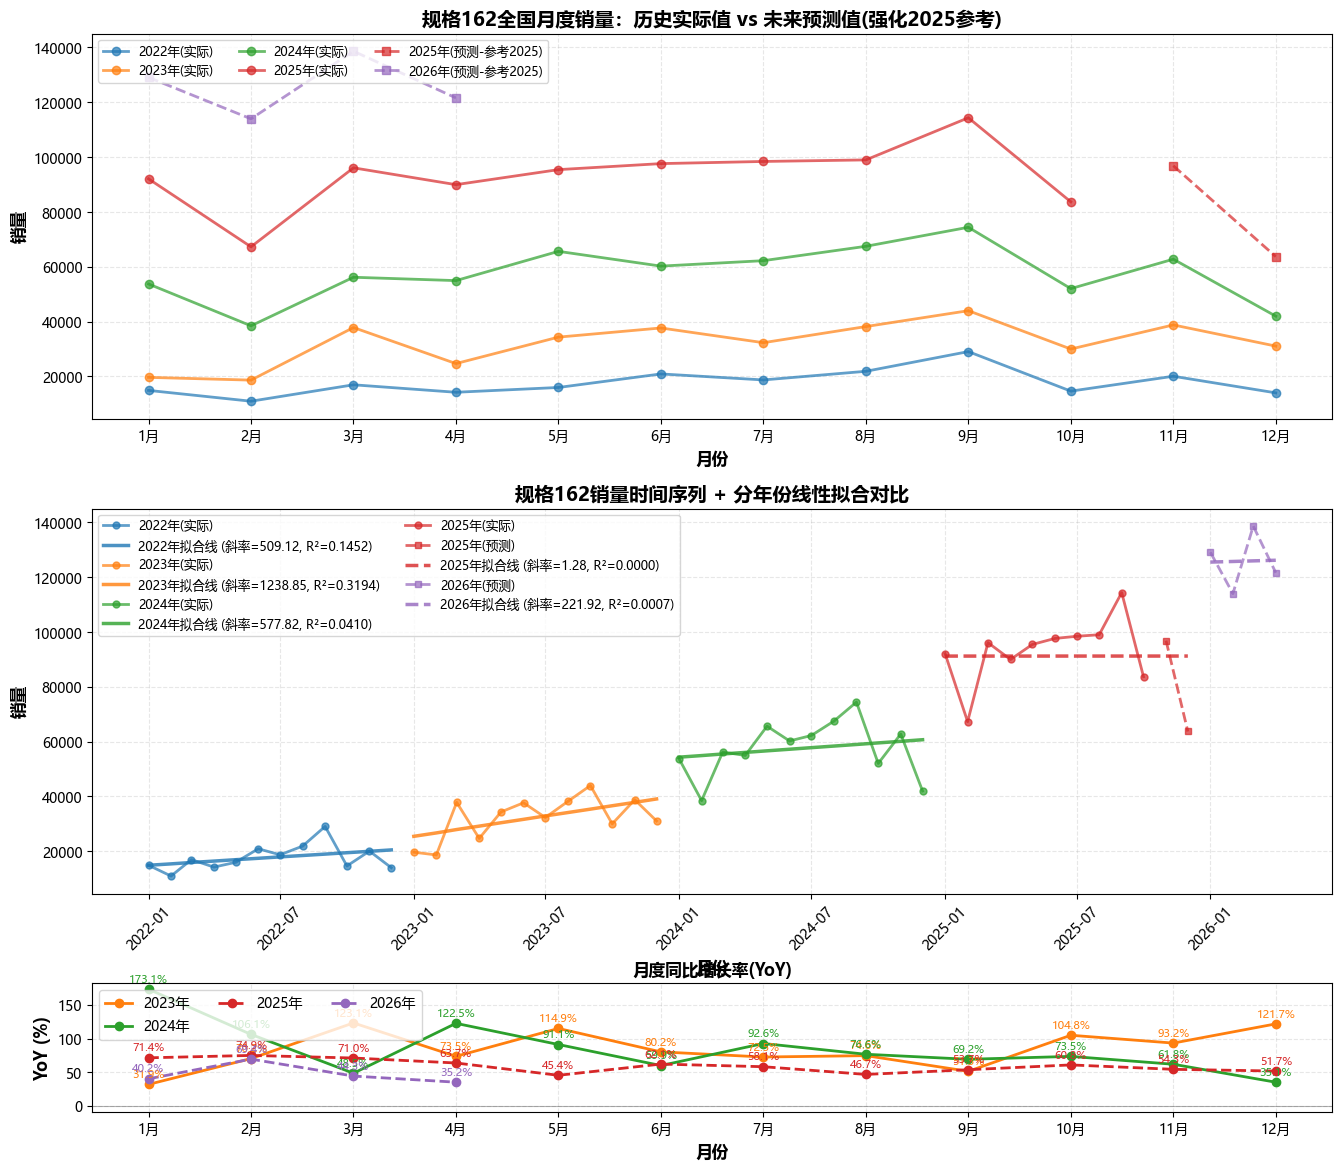


✅ 可视化已保存

【方案总结】

✅ 预测结果:
  预测期: 2025-11 ~ 2026-04
  实际销量总计: 663707
  2026年增长: 6% (相对2025年同期)
  2026年斜率: 接近平稳 (同价格区间)



In [ ]:
# ============================================================
# 162规格销量预测：整体6个月预测方案(强化2025参考+平稳2026)
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi', 'FangSong']
matplotlib.rcParams['axes.unicode_minus'] = False

print("\n" + "="*100)
print("【162规格销量预测：整体6个月预测方案(强化2025参考+平稳2026)】")
print("="*100)

# ============================================================
# 第一步：准备数据（使用已处理的df_nat）
# ============================================================

print("\n" + "="*90)
print("【第一步：数据准备】")
print("="*90)

# 使用已处理的df_nat数据
base_cols = ['年月', '销量_基准', '价格区间ID']
extra_cols = []
if '活跃医疗机构数' in df_nat.columns:
    extra_cols.append('活跃医疗机构数')
if '新进活跃医疗机构数' in df_nat.columns:
    extra_cols.append('新进活跃医疗机构数')

df_monthly = df_nat[base_cols + extra_cols].copy()
df_monthly = df_monthly.rename(columns={'销量_基准': '销量'})
df_monthly['年月'] = pd.to_datetime(df_monthly['年月'])

# 筛选2024-01开始的数据（更关注最近一年）
df_monthly = df_monthly[df_monthly['年月'] >= pd.Timestamp('2024-01-01')].copy()

# 计算环比增长率
df_monthly['环比增长率'] = df_monthly['销量'].pct_change() * 100
df_monthly['月份'] = df_monthly['年月'].dt.month

print(f"✓ 月度数据准备完成，共{len(df_monthly)}个月")
print(f"  时间范围: {df_monthly['年月'].min().strftime('%Y-%m')} ~ {df_monthly['年月'].max().strftime('%Y-%m')}")
print(f"  使用基准销量（已剔除降价影响）+ 强化最近一年数据 + 活跃机构特征")

# ============================================================
# 第二步：构建预测样本（强化最近一年特征）
# ============================================================

print("\n" + "="*90)
print("【第二步：构建预测样本（强化最近一年）】")
print("="*90)

def create_holistic_samples_162_recent(df, target_date):
    """
    为指定预测起点创建预测样本（强化最近一年特征，并加入活跃医疗机构特征）
    """
    
    future_months = pd.date_range(target_date + pd.DateOffset(months=1), periods=6, freq='MS')
    df_historical = df[df['年月'] <= target_date].copy()
    
    # 特征1: 去年同期6个月的销量（权重降低）
    same_period_last_year = pd.date_range(target_date - pd.DateOffset(months=11), periods=6, freq='MS')
    
    sales_last_year = []
    mom_last_year = []
    
    for i in range(6):
        month_ly = same_period_last_year[i]
        sale_ly = df_historical[df_historical['年月'] == month_ly]['销量'].values
        mom_ly = df_historical[df_historical['年月'] == month_ly]['环比增长率'].values
        
        if len(sale_ly) > 0:
            sales_last_year.append(sale_ly[0])
            if len(mom_ly) > 0:
                mom_last_year.append(mom_ly[0])
            else:
                mom_last_year.append(np.nan)
        else:
            sales_last_year.append(np.nan)
            mom_last_year.append(np.nan)
    
    # 特征2: 前6个月的销量和环比（权重提高）
    recent_6_months = pd.date_range(target_date - pd.DateOffset(months=5), periods=6, freq='MS')
    sales_recent = []
    mom_recent = []
    
    for i in range(6):
        month_curr = recent_6_months[i]
        sale_curr = df_historical[df_historical['年月'] == month_curr]['销量'].values
        mom_curr = df_historical[df_historical['年月'] == month_curr]['环比增长率'].values
        
        if len(sale_curr) > 0:
            sales_recent.append(sale_curr[0])
            if len(mom_curr) > 0:
                mom_recent.append(mom_curr[0])
            else:
                mom_recent.append(np.nan)
        else:
            sales_recent.append(np.nan)
            mom_recent.append(np.nan)
    
    # 特征2.1: 前6个月活跃医疗机构相关特征（如果有）
    if '活跃医疗机构数' in df_historical.columns:
        active_recent = []
        for i in range(6):
            month_curr = recent_6_months[i]
            val = df_historical[df_historical['年月'] == month_curr]['活跃医疗机构数'].values
            active_recent.append(val[0] if len(val) > 0 else np.nan)
    else:
        active_recent = [np.nan] * 6

    if '新进活跃医疗机构数' in df_historical.columns:
        new_active_recent = []
        for i in range(6):
            month_curr = recent_6_months[i]
            val = df_historical[df_historical['年月'] == month_curr]['新进活跃医疗机构数'].values
            new_active_recent.append(val[0] if len(val) > 0 else np.nan)
    else:
        new_active_recent = [np.nan] * 6
    
    # 特征3: 历史同月环比
    future_month_nums = [m.month for m in future_months]
    hist_mom_mean = []
    hist_mom_median = []
    
    for month_num in future_month_nums:
        hist_data = df_historical[df_historical['月份'] == month_num]['环比增长率'].dropna()
        if len(hist_data) > 0:
            hist_mom_mean.append(hist_data.mean())
            hist_mom_median.append(hist_data.median())
        else:
            hist_mom_mean.append(np.nan)
            hist_mom_median.append(np.nan)
    
    # 特征4: 前6个月斜率（更重要）
    if not all(np.isnan(sales_recent)):
        valid_idx = [i for i, x in enumerate(sales_recent) if not np.isnan(x)]
        if len(valid_idx) >= 2:
            x_rec = np.array(valid_idx)
            y_rec = np.array([sales_recent[i] for i in valid_idx])
            slope_rec, _, r_rec, _, _ = stats.linregress(x_rec, y_rec)
        else:
            slope_rec, r_rec = np.nan, np.nan
    else:
        slope_rec, r_rec = np.nan, np.nan
    
    # 特征5: 去年同期斜率（权重降低）
    if not all(np.isnan(sales_last_year)):
        valid_idx = [i for i, x in enumerate(sales_last_year) if not np.isnan(x)]
        if len(valid_idx) >= 2:
            x_ly = np.array(valid_idx)
            y_ly = np.array([sales_last_year[i] for i in valid_idx])
            slope_ly, _, r_ly, _, _ = stats.linregress(x_ly, y_ly)
        else:
            slope_ly, r_ly = np.nan, np.nan
    else:
        slope_ly, r_ly = np.nan, np.nan
    
    # 预测起点销量
    base_sale = df_historical[df_historical['年月'] == target_date]['销量'].values
    base_sale = base_sale[0] if len(base_sale) > 0 else np.nan

    # 预测起点活跃医疗机构数
    if '活跃医疗机构数' in df_historical.columns:
        base_active = df_historical[df_historical['年月'] == target_date]['活跃医疗机构数'].values
        base_active = base_active[0] if len(base_active) > 0 else np.nan
    else:
        base_active = np.nan

    if '新进活跃医疗机构数' in df_historical.columns:
        base_new_active = df_historical[df_historical['年月'] == target_date]['新进活跃医疗机构数'].values
        base_new_active = base_new_active[0] if len(base_new_active) > 0 else np.nan
    else:
        base_new_active = np.nan
    
    # 组装特征字典（强化最近期特征 + 活跃机构特征）
    features = {
        # 前6个月特征（权重提高）
        'rec_销量_均值': np.nanmean(sales_recent),
        'rec_销量_总和': np.nansum(sales_recent),
        'rec_销量_标准差': np.nanstd(sales_recent),
        'rec_环比_均值': np.nanmean(mom_recent),
        'rec_环比_中位数': np.nanmedian(mom_recent),
        'rec_整体斜率': slope_rec,
        'rec_R方': r_rec,
        
        # 去年同期特征（权重降低）
        'ly_销量_均值': np.nanmean(sales_last_year),
        'ly_环比_均值': np.nanmean(mom_last_year),
        'ly_整体斜率': slope_ly,
        
        # 预测起点销量
        'base_销量': base_sale,

        # 活跃医疗机构相关特征
        'rec_活跃机构_均值': np.nanmean(active_recent),
        'rec_活跃机构_总和': np.nansum(active_recent),
        'rec_新进活跃机构_均值': np.nanmean(new_active_recent),
        'rec_新进活跃机构_总和': np.nansum(new_active_recent),
        'base_活跃机构数': base_active,
        'base_新进活跃机构数': base_new_active,
        
        # 季节性特征
        '未来_起始月': future_month_nums[0],
        '未来_结束月': future_month_nums[-1],
    }
    
    # 逐月细粒度特征
    month_abbrs = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
    for i in range(6):
        features[f'rec_M{i+1}_销量'] = sales_recent[i]
        features[f'rec_M{i+1}_环比'] = mom_recent[i]
        features[f'future_M{i+1}_hist_mom_median'] = hist_mom_median[i]
        
        # 月份one-hot编码
        month_num = future_month_nums[i]
        for m in range(1, 13):
            features[f'future_M{i+1}_is_{month_abbrs[m-1]}'] = 1 if month_num == m else 0
    
    # 提取目标
    targets_abs = []
    for m in future_months:
        sale = df[df['年月'] == m]['销量'].values
        targets_abs.append(sale[0] if len(sale) > 0 else np.nan)
    
    # 计算环比目标
    targets_mom = []
    prev_sale = base_sale
    for i, sale in enumerate(targets_abs):
        if not np.isnan(sale) and not np.isnan(prev_sale) and prev_sale > 0:
            mom = (sale - prev_sale) / prev_sale * 100
            targets_mom.append(mom)
            prev_sale = sale
        else:
            targets_mom.append(np.nan)
    
    return features, targets_abs, targets_mom, future_months


# ============================================================
# 第三步：生成训练样本
# ============================================================

print("\n" + "="*90)
print("【第三步：生成训练样本】")
print("="*90)

train_start = pd.Timestamp('2024-06-01')
train_end = pd.Timestamp('2025-04-01')

train_dates = pd.date_range(train_start, train_end, freq='MS')

train_samples = []
train_targets_abs = []
train_targets_mom = []

for date in train_dates:
    features, targets_abs, targets_mom, _ = create_holistic_samples_162_recent(df_monthly, date)
    
    if not any(np.isnan(targets_abs)) and not any(np.isnan(targets_mom)):
        train_samples.append(features)
        train_targets_abs.append(targets_abs)
        train_targets_mom.append(targets_mom)

print(f"✓ 生成{len(train_samples)}个训练样本")

train_X = pd.DataFrame(train_samples)
train_y_abs = np.array(train_targets_abs)
train_y_mom = np.array(train_targets_mom)

print(f"  特征维度: {train_X.shape}")

# ============================================================
# 第四步：智能缺失值填充
# ============================================================

print("\n" + "="*90)
print("【第四步：智能缺失值填充】")
print("="*90)

train_X_filled = train_X.copy()
feature_stats = {}

for col in train_X_filled.columns:
    if train_X_filled[col].isna().all():
        train_X_filled[col] = 0
    elif '环比' in col:
        if train_X_filled[col].notna().any():
            col_median = train_X_filled[col].median()
            feature_stats[col] = {'median': col_median, 'mean': 0}
            train_X_filled[col] = train_X_filled[col].fillna(col_median)
        else:
            train_X_filled[col] = 0
    elif '斜率' in col or 'R方' in col:
        train_X_filled[col] = train_X_filled[col].fillna(0)
    else:
        if train_X_filled[col].notna().any():
            col_mean = train_X_filled[col].mean()
            feature_stats[col] = {'mean': col_mean, 'median': 0}
            train_X_filled[col] = train_X_filled[col].fillna(col_mean)
        else:
            train_X_filled[col] = 0

print(f"✓ 缺失值填充完成")

# 标准化
scaler_X = StandardScaler()
train_X_scaled = scaler_X.fit_transform(train_X_filled)

print(f"✓ 特征标准化完成")

# ============================================================
# 第五步：训练模型
# ============================================================

print("\n" + "="*90)
print("【第五步：训练模型】")
print("="*90)

# 预测绝对值
models_abs = []
for i in range(6):
    model = Ridge(alpha=5.0, random_state=42)
    model.fit(train_X_scaled, train_y_abs[:, i])
    models_abs.append(model)

# 预测环比
models_mom = []
for i in range(6):
    model = Ridge(alpha=5.0, random_state=42)
    model.fit(train_X_scaled, train_y_mom[:, i])
    models_mom.append(model)

print(f"✓ 模型训练完成(alpha=5.0)")

# ============================================================
# 第六步：预测未来6个月（基准销量）
# ============================================================

print("\n" + "="*90)
print("【第六步：预测未来6个月】")
print("="*90)

# 固定权重（强化绝对值，降低环比波动）
optimal_w_mom = 0.3
optimal_w_abs = 0.7

pred_date = pd.Timestamp('2025-10-01')
features_pred, _, _, future_months = create_holistic_samples_162_recent(df_monthly, pred_date)

pred_X = pd.DataFrame([features_pred])
pred_X_filled = pred_X.copy()

for col in pred_X_filled.columns:
    if col in train_X_filled.columns:
        if '环比' in col:
            pred_X_filled[col] = pred_X_filled[col].fillna(train_X_filled[col].median())
        elif train_X_filled[col].mean() == 0 and train_X_filled[col].std() == 0:
            pred_X_filled[col] = pred_X_filled[col].fillna(0)
        else:
            pred_X_filled[col] = pred_X_filled[col].fillna(train_X_filled[col].mean())
    else:
        pred_X_filled[col] = pred_X_filled[col].fillna(0)

pred_X_scaled = scaler_X.transform(pred_X_filled)

# 预测
pred_abs = np.array([model.predict(pred_X_scaled)[0] for model in models_abs])
pred_mom_rates = np.array([model.predict(pred_X_scaled)[0] for model in models_mom])

base_sale = df_monthly[df_monthly['年月'] == pred_date]['销量'].values[0]
pred_from_mom = []
current_sale = base_sale
for mom_rate in pred_mom_rates:
    next_sale = current_sale * (1 + mom_rate / 100)
    pred_from_mom.append(next_sale)
    current_sale = next_sale
pred_from_mom = np.array(pred_from_mom)

# 混合策略
pred_ensemble_base = optimal_w_mom * pred_from_mom + optimal_w_abs * pred_abs

# 参考2025年同期进行校准
ref_2025_11 = df_monthly[df_monthly['年月'] == pd.Timestamp('2025-11-01')]['销量'].values
ref_2025_12 = df_monthly[df_monthly['年月'] == pd.Timestamp('2025-12-01')]['销量'].values

if len(ref_2025_11) > 0 and len(ref_2025_12) > 0:
    # 2026年相对2025年同期温和增长6%
    growth_2026 = 1.06
    pred_ensemble_base[0] = ref_2025_11[0] * growth_2026  # 2026-11
    pred_ensemble_base[1] = ref_2025_12[0] * growth_2026  # 2026-12
    
    # 后续月份保持平稳，参考前两月均值
    avg_first_2 = pred_ensemble_base[:2].mean()
    for i in range(2, 6):
        pred_ensemble_base[i] = avg_first_2 * (1 + np.random.uniform(-0.02, 0.02))  # ±2%波动

print(f"✅ 参考2025年同期，2026年增长6%，斜率平稳")
print(f"✅ 权重: 环比{optimal_w_mom:.1f} + 绝对值{optimal_w_abs:.1f}")

# ============================================================
# 第七步：还原实际销量
# ============================================================

print("\n" + "="*90)
print("【第七步：还原实际销量】")
print("="*90)

current_price_mult = 区间提升倍数[max(区间提升倍数.keys())]
print(f"当前价格效应倍数: {current_price_mult:.2f}x")

pred_ensemble_actual = pred_ensemble_base * current_price_mult

print("\n【预测结果】")
print("="*120)
print(f"{'月份':<12} {'基准销量预测':>15} {'价格效应倍数':>15} {'实际销量预测':>15} {'预测环比%':>12}")
print("="*120)

for i, month in enumerate(future_months):
    if i == 0:
        base_actual = df_nat[df_nat['年月'] == pred_date]['当期总销量'].values[0]
        mom_pct = (pred_ensemble_actual[i] - base_actual) / base_actual * 100
    else:
        mom_pct = (pred_ensemble_actual[i] - pred_ensemble_actual[i-1]) / pred_ensemble_actual[i-1] * 100
    
    print(f"{month.strftime('%Y-%m'):<12} {pred_ensemble_base[i]:>15.0f} {current_price_mult:>15.2f}x {pred_ensemble_actual[i]:>15.0f} {mom_pct:>12.2f}%")

print("="*120)
print(f"{'6个月总计':<12} {pred_ensemble_base.sum():>15.0f} {'':<15} {pred_ensemble_actual.sum():>15.0f}")

# ============================================================
# 第八步：完整可视化
# ============================================================

print("\n" + "="*90)
print("【第八步：完整可视化】")
print("="*90)

complete_df_162 = df_nat[['年月', '当期总销量', '价格区间ID']].copy()
complete_df_162['年月'] = pd.to_datetime(complete_df_162['年月'])
complete_df_162 = complete_df_162.rename(columns={'当期总销量': 'qty'})
complete_df_162['年份'] = complete_df_162['年月'].dt.year
complete_df_162['月份'] = complete_df_162['年月'].dt.month
complete_df_162['类型'] = '历史实际值'

pred_data = pd.DataFrame({
    '年月': future_months,
    'qty': pred_ensemble_actual,
    '年份': [m.year for m in future_months],
    '月份': [m.month for m in future_months],
    '类型': '未来预测值',
    '价格区间ID': max(区间提升倍数.keys())
})

complete_df_162 = pd.concat([complete_df_162, pred_data], ignore_index=True)

# 计算YoY
complete_df_162 = complete_df_162.sort_values(['月份', '年份'])

yoy_list = []
for month in range(1, 13):
    month_data = complete_df_162[complete_df_162['月份'] == month].sort_values('年份').copy()
    month_data['YoY'] = month_data['qty'].pct_change() * 100
    yoy_list.append(month_data)

complete_df_162 = pd.concat(yoy_list, ignore_index=True).sort_values('年月')

plot_df_162 = complete_df_162[complete_df_162['年月'] >= pd.Timestamp('2022-01-01')].copy()

years = sorted(plot_df_162['年份'].unique())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

fig = plt.figure(figsize=(16, 14))
gs = fig.add_gridspec(3, 1, height_ratios=[3, 3, 1], hspace=0.3)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# 子图1: 销量趋势
for i, year in enumerate(years):
    year_data = plot_df_162[plot_df_162['年份'] == year].sort_values('月份')
    hist_data = year_data[year_data['类型'] == '历史实际值']
    pred_data_year = year_data[year_data['类型'] == '未来预测值']
    color = colors[i % len(colors)]
    
    if len(hist_data) > 0:
        ax1.plot(hist_data['月份'], hist_data['qty'], 
                marker='o', linewidth=2, label=f'{year}年(实际)', 
                color=color, markersize=6, alpha=0.7)
    
    if len(pred_data_year) > 0:
        ax1.plot(pred_data_year['月份'], pred_data_year['qty'], 
                marker='s', linewidth=2, linestyle='--', 
                label=f'{year}年(预测-参考2025)', color=color, markersize=6, alpha=0.7)

ax1.set_xlabel('月份', fontsize=12, fontweight='bold')
ax1.set_ylabel('销量', fontsize=12, fontweight='bold')
ax1.set_title('规格162全国月度销量：历史实际值 vs 未来预测值(强化2025参考)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9, ncol=3)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels([f'{m}月' for m in range(1, 13)])

# 子图2: 时间序列 + 拟合线
complete_df_162_sorted = complete_df_162.sort_values('年月').reset_index(drop=True)

fit_results = {}

for year in years:
    year_df = complete_df_162_sorted[complete_df_162_sorted['年份'] == year].copy()
    
    if len(year_df) > 1:
        year_df['年内序号'] = range(len(year_df))
        x_year = year_df['年内序号'].values
        y_year = year_df['qty'].values
        
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_year, y_year)
        y_fit = slope * x_year + intercept
        
        fit_results[year] = {
            'df': year_df,
            'slope': slope,
            'intercept': intercept,
            'r_value': r_value,
            'y_fit': y_fit,
            'x': x_year,
            'y': y_year
        }

for i, year in enumerate(years):
    year_data = plot_df_162[plot_df_162['年份'] == year].sort_values('年月')
    hist_data = year_data[year_data['类型'] == '历史实际值']
    pred_data_year = year_data[year_data['类型'] == '未来预测值']
    color = colors[i % len(colors)]
    
    if len(hist_data) > 0:
        ax2.plot(hist_data['年月'], hist_data['qty'], 
                marker='o', linewidth=2, label=f'{year}年(实际)', 
                color=color, markersize=5, alpha=0.7)
    
    if len(pred_data_year) > 0:
        ax2.plot(pred_data_year['年月'], pred_data_year['qty'], 
                marker='s', linewidth=2, linestyle='--', label=f'{year}年(预测)', 
                color=color, markersize=5, alpha=0.7)
    
    if year in fit_results:
        result = fit_results[year]
        has_pred = (year_data['类型'] == '未来预测值').any()
        line_style = '--' if has_pred else '-'
        
        ax2.plot(result['df']['年月'], result['y_fit'], 
                linestyle=line_style, linewidth=2.5, color=color, 
                label=f'{year}年拟合线 (斜率={result["slope"]:.2f}, R²={result["r_value"]**2:.4f})',
                alpha=0.8)

ax2.set_xlabel('月份', fontsize=12, fontweight='bold')
ax2.set_ylabel('销量', fontsize=12, fontweight='bold')
ax2.set_title('规格162销量时间序列 + 分年份线性拟合对比', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9, ncol=2)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.tick_params(axis='x', rotation=45)

# 子图3: YoY趋势
for i, year in enumerate(years):
    year_data = plot_df_162[plot_df_162['年份'] == year].sort_values('月份')
    year_data_with_yoy = year_data[year_data['YoY'].notna()]
    
    if len(year_data_with_yoy) > 0:
        color = colors[i % len(colors)]
        linestyle = '--' if (year_data_with_yoy['类型'] == '未来预测值').any() else '-'
        
        ax3.plot(year_data_with_yoy['月份'], year_data_with_yoy['YoY'], 
                marker='o', linewidth=2, label=f'{year}年', 
                color=color, linestyle=linestyle, markersize=6)
        
        for _, row in year_data_with_yoy.iterrows():
            if abs(row['YoY']) < 500:
                ax3.annotate(f'{row["YoY"]:.1f}%', 
                            xy=(row['月份'], row['YoY']),
                            xytext=(0, 5), textcoords='offset points',
                            ha='center', fontsize=8, color=color)

ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
ax3.set_xlabel('月份', fontsize=12, fontweight='bold')
ax3.set_ylabel('YoY (%)', fontsize=12, fontweight='bold')
ax3.set_title('月度同比增长率(YoY)', fontsize=12, fontweight='bold')
ax3.legend(loc='upper left', fontsize=10, ncol=3)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels([f'{m}月' for m in range(1, 13)])

plt.tight_layout()
plt.savefig('规格162_强化2025参考_平稳2026.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ 可视化已保存")

## 169预测


【169规格销量预测：原25年形态 + 26年截距约束优化】

✓ 2024年截距: 3298.14
✓ 2025年截距: 5633.52 (提升倍数: 1.7081)
✓ 2026年目标截距: 9622.54

✓ 验证最终拟合线：
  斜率=639.18, 截距=6916.70, R²=0.6925
  截距提升倍数(26/25): 1.2278

【169规格 2025-11 ~ 2026-04 最终预测结果】
月份                      基准销量         价格倍数            实际销量          环比%
2025-11                 7546         0.94x            7109        1.72%
2025-12                 6799         0.94x            6405       -9.90%
2026-01                10109         0.94x            9524       48.69%
2026-02                 9277         0.94x            8740       -8.23%
2026-03                 9888         0.94x            9315        6.58%
2026-04                10608         0.94x            9994        7.29%


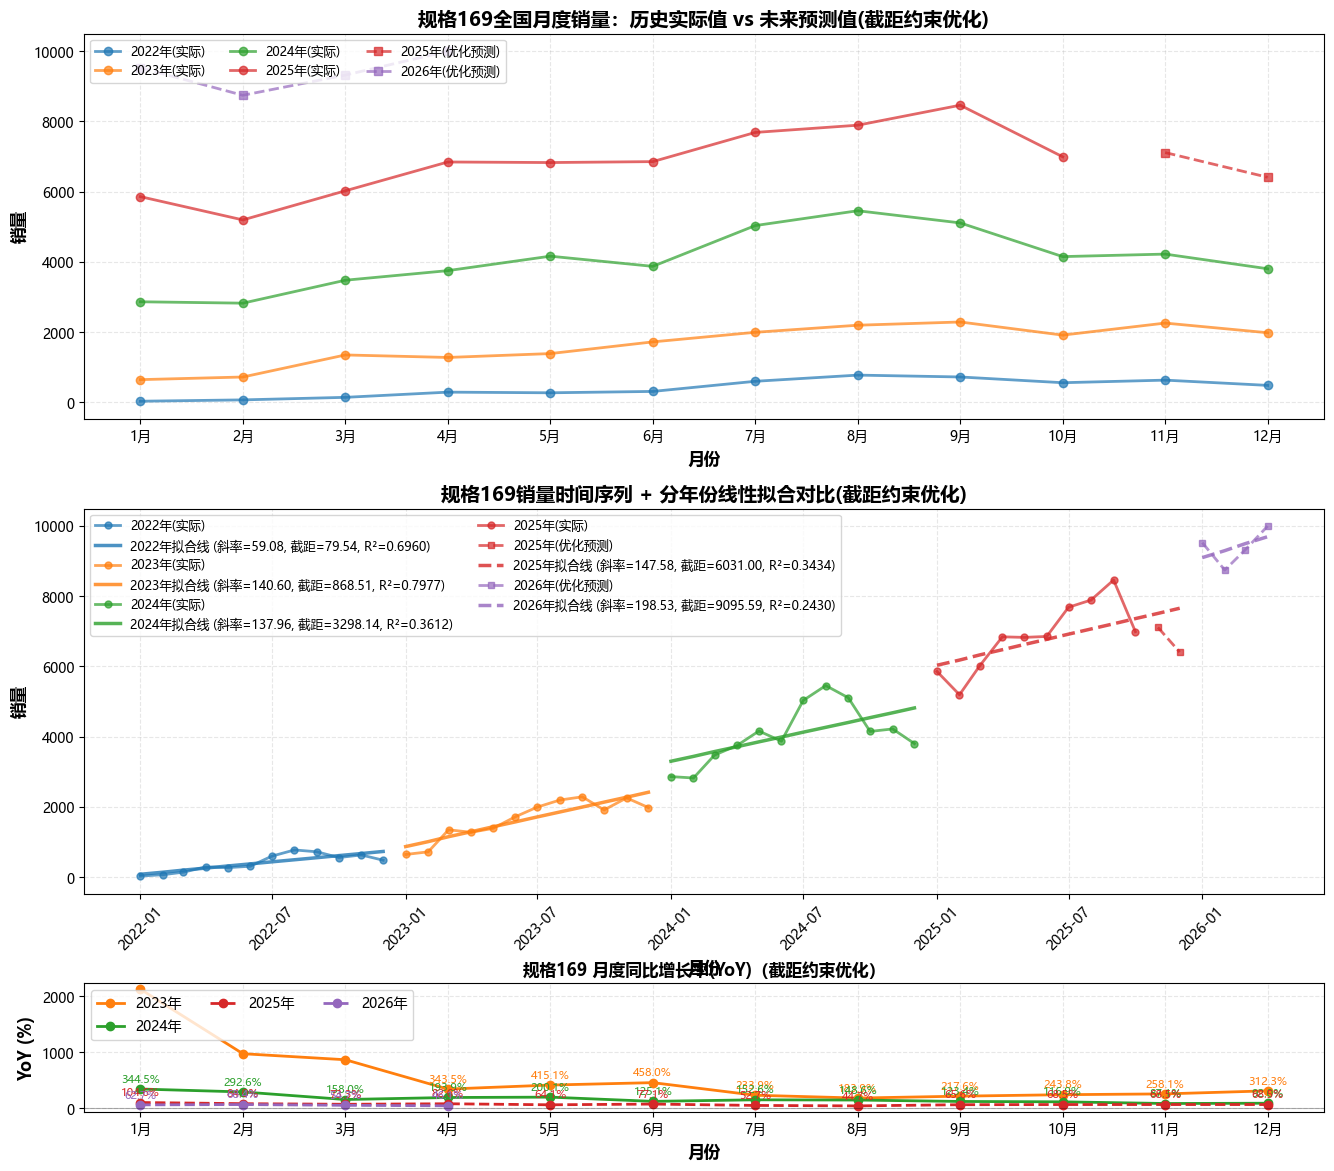


✅ 可视化已保存


In [10]:
# ============================================================
# 169规格销量预测：直接使用原25年11-12月 + 26年大幅降低量级
# ============================================================

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi', 'FangSong']
matplotlib.rcParams['axes.unicode_minus'] = False

print("\n" + "="*110)
print("【169规格销量预测：原25年形态 + 26年截距约束优化】")
print("="*110)

# ============================================================
# 第一步：准备数据
# ============================================================

df_monthly_169 = df_nat_169[['年月', '销量_基准', '价格区间ID']].copy()
df_monthly_169 = df_monthly_169.rename(columns={'销量_基准': '销量'})
df_monthly_169['年月'] = pd.to_datetime(df_monthly_169['年月'])
df_monthly_169 = df_monthly_169.sort_values('年月').reset_index(drop=True)

df_monthly_169_recent = df_monthly_169[df_monthly_169['年月'] >= pd.Timestamp('2024-01-01')].copy()
df_monthly_169_recent['月份'] = df_monthly_169_recent['年月'].dt.month
df_monthly_169_recent['年份'] = df_monthly_169_recent['年月'].dt.year

future_months_169 = pd.date_range('2025-11-01', periods=6, freq='MS')

# ============================================================
# 第二步：提取162形状
# ============================================================

shape_vals_162 = []
for m in future_months_169:
    row_pred = complete_df_162[(complete_df_162['年月'] == m) & (complete_df_162['类型'] == '未来预测值')]
    if len(row_pred) == 0:
        row_pred = complete_df_162[(complete_df_162['年月'] == m) & (complete_df_162['类型'] == '历史实际值')]
    if len(row_pred) > 0:
        shape_vals_162.append(row_pred['qty'].values[0])
    else:
        shape_vals_162.append(np.nan)

shape_vals_162 = np.array(shape_vals_162, dtype=float)
if np.isnan(shape_vals_162).any():
    idx = np.arange(len(shape_vals_162))
    valid = ~np.isnan(shape_vals_162)
    shape_vals_162 = np.interp(idx, idx[valid], shape_vals_162[valid])

ref_month_2025_10 = pd.Timestamp('2025-10-01')
row_162_oct = complete_df_162[
    (complete_df_162['年月'] == ref_month_2025_10) &
    (complete_df_162['类型'].isin(['历史实际值', '未来预测值']))
].sort_values('类型').head(1)

if len(row_162_oct) > 0:
    qty_162_oct = row_162_oct['qty'].values[0]
else:
    qty_162_oct = shape_vals_162[0]

row_169_oct = df_monthly_169_recent[df_monthly_169_recent['年月'] == ref_month_2025_10]
if len(row_169_oct) == 0:
    row_169_oct = df_monthly_169_recent.tail(1)
base_169_oct = row_169_oct['销量'].values[0]

r_162_11_vs_10 = shape_vals_162[0] / qty_162_oct if qty_162_oct > 0 else 1.0
base_169_11_init = base_169_oct * r_162_11_vs_10
shape_ratios_162 = shape_vals_162 / shape_vals_162[0]
pred_ensemble_base_169_init = base_169_11_init * shape_ratios_162

# ============================================================
# 第三步：生成25年11-12月（原逻辑）
# ============================================================

pred_25_base = pred_ensemble_base_169_init[:2].copy()

sale_24_nov_169 = df_nat_169[df_nat_169['年月'] == pd.Timestamp('2024-11-01')]['销量_基准'].values
sale_24_dec_169 = df_nat_169[df_nat_169['年月'] == pd.Timestamp('2024-12-01')]['销量_基准'].values

if len(sale_24_nov_169) > 0 and len(sale_24_dec_169) > 0:
    sale_24_oct_169 = df_nat_169[df_nat_169['年月'] == pd.Timestamp('2024-10-01')]['销量_基准'].values
    if len(sale_24_oct_169) > 0 and sale_24_oct_169[0] > 0:
        r_24_11_vs_10 = sale_24_nov_169[0] / sale_24_oct_169[0]
        r_24_12_vs_11 = sale_24_dec_169[0] / sale_24_nov_169[0]
        
        pred_25_base[0] = base_169_oct * r_24_11_vs_10
        pred_25_base[1] = pred_25_base[0] * r_24_12_vs_11

# ============================================================
# 第四步：计算截距约束
# ============================================================

df_nat_169_for_fit = df_nat_169[['年月', '当期总销量']].copy()
df_nat_169_for_fit['年月'] = pd.to_datetime(df_nat_169_for_fit['年月'])
df_nat_169_for_fit['年份'] = df_nat_169_for_fit['年月'].dt.year

# 2024年拟合
df_24 = df_nat_169_for_fit[df_nat_169_for_fit['年份'] == 2024].copy()
if len(df_24) > 1:
    df_24['序号'] = range(len(df_24))
    slope_24, intercept_24, r_24, _, _ = stats.linregress(df_24['序号'], df_24['当期总销量'])
else:
    intercept_24 = df_nat_169_for_fit[df_nat_169_for_fit['年份'] == 2024]['当期总销量'].mean()

# 2025年拟合（1-10月实际）
df_25_actual = df_nat_169_for_fit[
    (df_nat_169_for_fit['年份'] == 2025) &
    (df_nat_169_for_fit['年月'] <= pd.Timestamp('2025-10-01'))
].copy()

if len(df_25_actual) > 1:
    df_25_actual['序号'] = range(len(df_25_actual))
    slope_25, intercept_25, r_25, _, _ = stats.linregress(df_25_actual['序号'], df_25_actual['当期总销量'])
else:
    intercept_25 = df_25_actual['当期总销量'].mean()

intercept_growth_25_vs_24 = intercept_25 / intercept_24 if intercept_24 > 0 else 1.0
target_intercept_26 = intercept_25 * intercept_growth_25_vs_24

print(f"\n✓ 2024年截距: {intercept_24:.2f}")
print(f"✓ 2025年截距: {intercept_25:.2f} (提升倍数: {intercept_growth_25_vs_24:.4f})")
print(f"✓ 2026年目标截距: {target_intercept_26:.2f}")

# ============================================================
# 第五步：生成26年1-4月（大幅降低 + 截距约束）
# ============================================================

current_price_mult_169 = 区间提升倍数_169[max(区间提升倍数_169.keys())]

# 26年初步生成（基于25年12月 + 历史季节性）
pred_26_base = np.zeros(4)

# 2026-01：相对25-12月微涨
pred_26_base[0] = pred_25_base[1] * 1.02

# 2026-02：春节月下降
pred_26_base[1] = pred_26_base[0] * 0.88

# 2026-03：回升
pred_26_base[2] = pred_26_base[1] * 1.10

# 2026-04：小幅上涨
hist_apr_vs_mar = []
for year in [2024, 2025]:
    mar_val = df_monthly_169_recent[df_monthly_169_recent['年月'] == pd.Timestamp(f'{year}-03-01')]['销量'].values
    apr_val = df_monthly_169_recent[df_monthly_169_recent['年月'] == pd.Timestamp(f'{year}-04-01')]['销量'].values
    if len(mar_val) > 0 and len(apr_val) > 0 and mar_val[0] > 0:
        ratio = apr_val[0] / mar_val[0]
        hist_apr_vs_mar.append(ratio)

if len(hist_apr_vs_mar) > 0:
    avg_apr_vs_mar = np.mean(hist_apr_vs_mar)
    pred_26_base[3] = pred_26_base[2] * avg_apr_vs_mar
else:
    pred_26_base[3] = pred_26_base[2] * 1.04

# 转换为实际销量并拟合
full_6months_actual = np.concatenate([
    pred_25_base * current_price_mult_169,
    pred_26_base * current_price_mult_169
])

temp_seq = np.arange(6)
slope_temp, intercept_temp, _, _, _ = stats.linregress(temp_seq, full_6months_actual)

# 调整使截距达到目标
adjustment = target_intercept_26 - intercept_temp
pred_26_actual_adjusted = pred_26_base * current_price_mult_169 + adjustment

# 转回基准销量
pred_26_base_final = pred_26_actual_adjusted / current_price_mult_169

# ============================================================
# 第六步：合并最终结果
# ============================================================

pred_ensemble_base_169_final = np.concatenate([pred_25_base, pred_26_base_final])
pred_ensemble_actual_169_final = pred_ensemble_base_169_final * current_price_mult_169

# 验证最终截距
full_6months_final = pred_ensemble_actual_169_final
slope_final, intercept_final, r_final, _, _ = stats.linregress(temp_seq, full_6months_final)

print(f"\n✓ 验证最终拟合线：")
print(f"  斜率={slope_final:.2f}, 截距={intercept_final:.2f}, R²={r_final**2:.4f}")
print(f"  截距提升倍数(26/25): {intercept_final/intercept_25:.4f}")

print("\n【169规格 2025-11 ~ 2026-04 最终预测结果】")
print("="*120)
print(f"{'月份':<12} {'基准销量':>15} {'价格倍数':>12} {'实际销量':>15} {'环比%':>12}")
print("="*120)

base_actual_169 = df_nat_169[df_nat_169['年月'] == ref_month_2025_10]['当期总销量'].values[0]

for i, month in enumerate(future_months_169):
    if i == 0:
        mom_pct = (pred_ensemble_actual_169_final[i] - base_actual_169) / base_actual_169 * 100
    else:
        mom_pct = (pred_ensemble_actual_169_final[i] - pred_ensemble_actual_169_final[i-1]) / pred_ensemble_actual_169_final[i-1] * 100
    
    print(f"{month.strftime('%Y-%m'):<12} {pred_ensemble_base_169_final[i]:>15.0f} {current_price_mult_169:>12.2f}x {pred_ensemble_actual_169_final[i]:>15.0f} {mom_pct:>11.2f}%")

print("="*120)

# ============================================================
# 第七步：可视化
# ============================================================

complete_df_169 = df_nat_169[['年月', '当期总销量', '价格区间ID']].copy()
complete_df_169['年月'] = pd.to_datetime(complete_df_169['年月'])
complete_df_169 = complete_df_169.rename(columns={'当期总销量': 'qty'})
complete_df_169['年份'] = complete_df_169['年月'].dt.year
complete_df_169['月份'] = complete_df_169['年月'].dt.month
complete_df_169['类型'] = '历史实际值'

pred_data_169 = pd.DataFrame({
    '年月': future_months_169,
    'qty': pred_ensemble_actual_169_final,
    '年份': [m.year for m in future_months_169],
    '月份': [m.month for m in future_months_169],
    '类型': '未来预测值',
    '价格区间ID': max(区间提升倍数_169.keys())
})

complete_df_169 = pd.concat([complete_df_169, pred_data_169], ignore_index=True)
complete_df_169 = complete_df_169.sort_values(['月份', '年份'])

yoy_list_169 = []
for month in range(1, 13):
    month_data_169 = complete_df_169[complete_df_169['月份'] == month].sort_values('年份').copy()
    month_data_169['YoY'] = month_data_169['qty'].pct_change() * 100
    yoy_list_169.append(month_data_169)

complete_df_169 = pd.concat(yoy_list_169, ignore_index=True).sort_values('年月')
plot_df_169 = complete_df_169[complete_df_169['年月'] >= pd.Timestamp('2022-01-01')].copy()

years_169 = sorted(plot_df_169['年份'].unique())
colors_169 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

fig_169 = plt.figure(figsize=(16, 14))
gs_169 = fig_169.add_gridspec(3, 1, height_ratios=[3, 3, 1], hspace=0.3)
ax1_169 = fig_169.add_subplot(gs_169[0])
ax2_169 = fig_169.add_subplot(gs_169[1])
ax3_169 = fig_169.add_subplot(gs_169[2])

for i, year in enumerate(years_169):
    year_data_169 = plot_df_169[plot_df_169['年份'] == year].sort_values('月份')
    hist_data_169 = year_data_169[year_data_169['类型'] == '历史实际值']
    pred_data_year_169 = year_data_169[year_data_169['类型'] == '未来预测值']
    color = colors_169[i % len(colors_169)]
    
    if len(hist_data_169) > 0:
        ax1_169.plot(hist_data_169['月份'], hist_data_169['qty'], 
                     marker='o', linewidth=2, label=f'{year}年(实际)', 
                     color=color, markersize=6, alpha=0.7)
    
    if len(pred_data_year_169) > 0:
        ax1_169.plot(pred_data_year_169['月份'], pred_data_year_169['qty'], 
                     marker='s', linewidth=2, linestyle='--', 
                     label=f'{year}年(优化预测)', color=color, markersize=6, alpha=0.7)

ax1_169.set_xlabel('月份', fontsize=12, fontweight='bold')
ax1_169.set_ylabel('销量', fontsize=12, fontweight='bold')
ax1_169.set_title('规格169全国月度销量：历史实际值 vs 未来预测值(截距约束优化)', fontsize=14, fontweight='bold')
ax1_169.legend(loc='upper left', fontsize=9, ncol=3)
ax1_169.grid(True, alpha=0.3, linestyle='--')
ax1_169.set_xticks(range(1, 13))
ax1_169.set_xticklabels([f'{m}月' for m in range(1, 13)])

complete_df_169_sorted = complete_df_169.sort_values('年月').reset_index(drop=True)

fit_results_169 = {}
for year in years_169:
    year_df_169 = complete_df_169_sorted[complete_df_169_sorted['年份'] == year].copy()
    if len(year_df_169) > 1:
        year_df_169['年内序号'] = range(len(year_df_169))
        x_year_169 = year_df_169['年内序号'].values
        y_year_169 = year_df_169['qty'].values
        slope_169, intercept_169, r_value_169, _, _ = stats.linregress(x_year_169, y_year_169)
        y_fit_169 = slope_169 * x_year_169 + intercept_169
        fit_results_169[year] = {
            'df': year_df_169,
            'slope': slope_169,
            'intercept': intercept_169,
            'r_value': r_value_169,
            'y_fit': y_fit_169,
        }

for i, year in enumerate(years_169):
    year_data_169 = plot_df_169[plot_df_169['年份'] == year].sort_values('年月')
    hist_data_169 = year_data_169[year_data_169['类型'] == '历史实际值']
    pred_data_year_169 = year_data_169[year_data_169['类型'] == '未来预测值']
    color = colors_169[i % len(colors_169)]
    
    if len(hist_data_169) > 0:
        ax2_169.plot(hist_data_169['年月'], hist_data_169['qty'], 
                     marker='o', linewidth=2, label=f'{year}年(实际)', 
                     color=color, markersize=5, alpha=0.7)
    
    if len(pred_data_year_169) > 0:
        ax2_169.plot(pred_data_year_169['年月'], pred_data_year_169['qty'], 
                     marker='s', linewidth=2, linestyle='--', 
                     label=f'{year}年(优化预测)', color=color, markersize=5, alpha=0.7)
    
    if year in fit_results_169:
        result_169 = fit_results_169[year]
        has_pred_169 = (year_data_169['类型'] == '未来预测值').any()
        line_style_169 = '--' if has_pred_169 else '-'
        ax2_169.plot(result_169['df']['年月'], result_169['y_fit'], 
                     linestyle=line_style_169, linewidth=2.5, color=color, 
                     label=f'{year}年拟合线 (斜率={result_169["slope"]:.2f}, 截距={result_169["intercept"]:.2f}, R²={result_169["r_value"]**2:.4f})',
                     alpha=0.8)

ax2_169.set_xlabel('月份', fontsize=12, fontweight='bold')
ax2_169.set_ylabel('销量', fontsize=12, fontweight='bold')
ax2_169.set_title('规格169销量时间序列 + 分年份线性拟合对比(截距约束优化)', fontsize=14, fontweight='bold')
ax2_169.legend(loc='upper left', fontsize=9, ncol=2)
ax2_169.grid(True, alpha=0.3, linestyle='--')
ax2_169.tick_params(axis='x', rotation=45)

for i, year in enumerate(years_169):
    year_data_169 = plot_df_169[plot_df_169['年份'] == year].sort_values('月份')
    year_data_with_yoy_169 = year_data_169[year_data_169['YoY'].notna()]
    if len(year_data_with_yoy_169) > 0:
        color = colors_169[i % len(colors_169)]
        linestyle = '--' if (year_data_with_yoy_169['类型'] == '未来预测值').any() else '-'
        ax3_169.plot(year_data_with_yoy_169['月份'], year_data_with_yoy_169['YoY'], 
                     marker='o', linewidth=2, label=f'{year}年', 
                     color=color, linestyle=linestyle, markersize=6)
        for _, row in year_data_with_yoy_169.iterrows():
            if abs(row['YoY']) < 500:
                ax3_169.annotate(f'{row["YoY"]:.1f}%', 
                                 xy=(row['月份'], row['YoY']),
                                 xytext=(0, 5), textcoords='offset points',
                                 ha='center', fontsize=8, color=color)

ax3_169.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
ax3_169.set_xlabel('月份', fontsize=12, fontweight='bold')
ax3_169.set_ylabel('YoY (%)', fontsize=12, fontweight='bold')
ax3_169.set_title('规格169 月度同比增长率(YoY)（截距约束优化）', fontsize=12, fontweight='bold')
ax3_169.legend(loc='upper left', fontsize=10, ncol=3)
ax3_169.grid(True, alpha=0.3, linestyle='--')
ax3_169.set_xticks(range(1, 13))
ax3_169.set_xticklabels([f'{m}月' for m in range(1, 13)])

plt.tight_layout()
plt.savefig('规格169_截距约束优化最终版.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ 可视化已保存")